# Superstore Project
Dataset containing Sales & Profits of a Superstore

-- Business Statistics & Insights | Master in Business Analytics & AI

The goal is to use the Superstore Sales dataset (9,994 transactions, 2014-2017) to produce work that directly maps to the five skill areas in the target role.

* Dataset: https://www.kaggle.com/datasets/vivek468/superstore-dataset-final

<img src="https://quivo.co/fileadmin/_processed_/8/b/csm_Online-Shop_big_e8834fc4db.jpg" width="1500">

> **Authors:** Ivana Caridad Lovera Ruiz & Linda  
> **Module:** Business Statistics & Insights - Master in Business Analytics & AI  
> **Merged:** June 2026


### Task 3 - Statistical Inference

## Methodology Notes

With n = 9,994 observations, almost every statistical test will return p < 0.05. A large sample makes it easy to detect tiny, practically meaningless differences. Throughout this analysis, statistical significance (p-value) is reported alongside **effect size** - the measure of how large the difference actually is. A finding is only business-relevant if it is both statistically significant and practically meaningful.

> **Significance level: alpha = 0.05 throughout this notebook.**  
> If p-value < 0.05, we reject H0 and conclude the effect is statistically significant.

Because the normality assumption is violated for all key variables (see Section 1), the primary hypothesis tests throughout this analysis are **non-parametric**: Kruskal-Wallis, Mann-Whitney U, Dunn's post-hoc, and Spearman correlation. Parametric ANOVA results are included alongside for reference and comparison.


---
## 0. Setup: Load Libraries and Data

In [107]:
ALPHA = 0.05
print(f'Significance level set: alpha = {ALPHA}')

Significance level set: alpha = 0.05


In [108]:
import sys
print(sys.executable)
print(sys.version)

/Users/ivanacaridad/Documents/GitHub/superstore_dataset/.venv/bin/python
3.9.13 (main, Aug 25 2022, 18:29:29) 
[Clang 12.0.0 ]


In [109]:
import subprocess
result = subprocess.run([sys.executable, '-m', 'pip', 'install', 'pingouin', 'scikit-posthocs'], capture_output=True, text=True)
print(result.stdout[-2000:])
print(result.stderr[-1000:])

kit-learn>=1.2->pingouin) (3.6.0)




In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import os
from scipy import stats
from scipy.stats import (shapiro, normaltest, mannwhitneyu,
    kruskal, spearmanr, chi2_contingency, t)
    
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.api as sm
import pingouin as pg
import scikit_posthocs as sp
from itertools import combinations

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# Load data
df = pd.read_parquet('../data/processed/superstore_clean.parquet')

# Align column name aliases
if 'Profit Margin' in df.columns and 'Profit Margin %' not in df.columns:
    df['Profit Margin %'] = df['Profit Margin']
if 'Order Quarter' not in df.columns:
    df['Order Quarter'] = df['Order Date'].dt.quarter
if 'Order Year' not in df.columns:
    df['Order Year'] = df['Order Date'].dt.year
if 'Discount Category' in df.columns and 'Discount Band' not in df.columns:
    df['Discount Band'] = df['Discount Category']

print(f'{df.shape[0]:,} rows x {df.shape[1]} columns loaded')
df.head()

9,994 rows x 34 columns loaded


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,State_abb,Profit Margin,Delivery Days,Year,Quarter,Month,Month_Name,Year_Month,Discount Category,Profit Margin %,Order Quarter,Order Year,Discount Band
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,KY,0.1600,3,2016,4,11,Nov,2016-11,No Discount,0.1600,4,2016,No Discount
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,KY,0.3000,3,2016,4,11,Nov,2016-11,No Discount,0.3000,4,2016,No Discount
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,CA,0.4700,4,2016,2,6,Jun,2016-06,No Discount,0.4700,2,2016,No Discount
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,FL,-0.4000,7,2015,4,10,Oct,2015-10,High (>40%),-0.4000,4,2015,High (>40%)
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,FL,0.1125,7,2015,4,10,Oct,2015-10,Low (1-20%),0.1125,4,2015,Low (1-20%)


---
## 1. Normality Testing

To assess the normality assumption, we combine visual inspection (Q-Q plots) with two quantitative tests: Shapiro-Wilk and D'Agostino-Pearson. Both evaluate H0 that the data comes from a normal distribution.

Given our large sample size (>9,900 observations), the Shapiro-Wilk test is highly sensitive to minor deviations. Therefore, p-values from both tests were interpreted alongside Q-Q plots.

**Implication:** Because the normality assumption is violated, the non-parametric **Kruskal-Wallis test** is the primary hypothesis test used throughout. ANOVA results are included for reference only.

### 1.1 Visual Check: Q-Q Plots


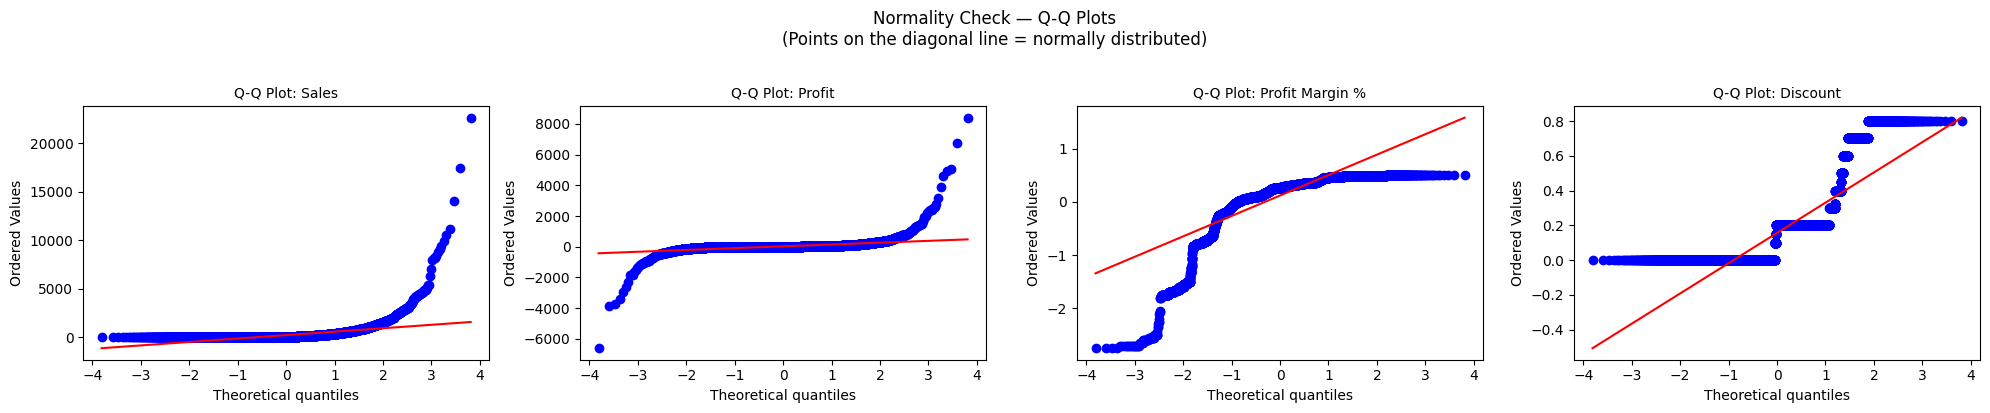

In [111]:
cols_to_test = ["Sales", "Profit", "Profit Margin %",
                "Discount", ]

fig, axes = plt.subplots(1, len(cols_to_test), figsize=(20, 4))

for i, col in enumerate(cols_to_test):
    stats.probplot(df[col].dropna(), dist="norm", plot=axes[i])
    axes[i].set_title(f"Q-Q Plot: {col}", fontsize=10)

plt.suptitle("Normality Check — Q-Q Plots\n"
             "(Points on the diagonal line = normally distributed)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("../output/images/normality_qq_plots.png",
            dpi=150, bbox_inches="tight")
plt.show()

### 1.2 Statistical Normality Tests: Shapiro-Wilk & D'Agostino-Pearson

In [112]:
from scipy.stats import shapiro, normaltest
import pandas as pd

# Define metrics to test
metrics = ['Sales', 'Profit', 'Profit Margin %', 'Discount', 'Quantity']

# Store results
normality_results = []

for metric in metrics:
    # Drop NaN values
    data = df[metric].dropna()
    
    # Shapiro-Wilk Test
    stat_shapiro, p_shapiro = shapiro(data)
    
    # D'Agostino-Pearson Test (normaltest)
    stat_dagostino, p_dagostino = normaltest(data)
    
    normality_results.append({
        'Metric': metric,
        'Shapiro-Wilk Statistic': stat_shapiro,
        'Shapiro-Wilk p-value': p_shapiro,
        "Shapiro-Wilk (p < 0.05)": "Non-Normal" if p_shapiro < 0.05 else "Normal",
        "D'Agostino-Pearson Statistic": stat_dagostino,
        "D'Agostino-Pearson p-value": p_dagostino,
        "D'Agostino-Pearson (p < 0.05)": "Non-Normal" if p_dagostino < 0.05 else "Normal"
    })

# Create summary DataFrame
normality_df = pd.DataFrame(normality_results)
print(normality_df.to_string(index=False))

         Metric  Shapiro-Wilk Statistic  Shapiro-Wilk p-value Shapiro-Wilk (p < 0.05)  D'Agostino-Pearson Statistic  D'Agostino-Pearson p-value D'Agostino-Pearson (p < 0.05)
          Sales                0.323327         4.065054e-105              Non-Normal                  18033.308498                         0.0                    Non-Normal
         Profit                0.257097         1.698786e-107              Non-Normal                  14363.736244                         0.0                    Non-Normal
Profit Margin %                0.676247          2.752409e-87              Non-Normal                   6118.367549                         0.0                    Non-Normal
       Discount                0.710706          1.030847e-84              Non-Normal                   2977.822121                         0.0                    Non-Normal
       Quantity                0.882391          1.518566e-65              Non-Normal                   2148.018022               

>**Findings:**
>To formally assess normality, the D'Agostino-Pearson test was applied to Sales, Profit, Profit Margin %, and Discount. All four variables yielded highly significant test statistics (p < 0.001), confirming non-normality. This is consistent with the visual assessment from QQ plots, which showed significant deviation from the theoretical normal line due to heavy right skew. Consequently, all subsequent hypothesis tests rely on non-parametric methods (Kruskal-Wallis and Dunn's post-hoc tests), which do not assume normality and are robust to the observed skewness.

---
## 2. Confidence Intervals

Two types of CI are reported:
1. **t-based 95% CI for the mean** (full dataset and by segment)
2. **Bootstrap 95% CI for the median** - model-free, no distributional assumptions

Both are computed across **Registration Segments** and **RFM Segments**.

### 2.1 Overall 95% CI for Key Variables (t-based)


In [113]:
from scipy.stats import t

def confidence_interval(data, confidence=0.95):
    n = len(data)
    mean = data.mean()
    se = stats.sem(data)  # standard error
    margin = se * t.ppf((1 + confidence) / 2, df=n - 1)
    return mean, mean - margin, mean + margin

variables = {
    'Sales':         df['Sales'],
    'Profit':        df['Profit'],
    'Profit Margin': df['Profit Margin'],
    'Delivery Days': df['Delivery Days']
}

print(f"{'Variable':<20} {'Mean':>10} {'95% CI Lower':>14} {'95% CI Upper':>14}")
print("-" * 60)
for name, data in variables.items():
    mean, lo, hi = confidence_interval(data)
    print(f"{name:<20} {mean:>10.2f} {lo:>14.2f} {hi:>14.2f}")

Variable                   Mean   95% CI Lower   95% CI Upper
------------------------------------------------------------
Sales                    229.86         217.64         242.08
Profit                    28.66          24.06          33.25
Profit Margin              0.12           0.11           0.13
Delivery Days              3.96           3.92           3.99


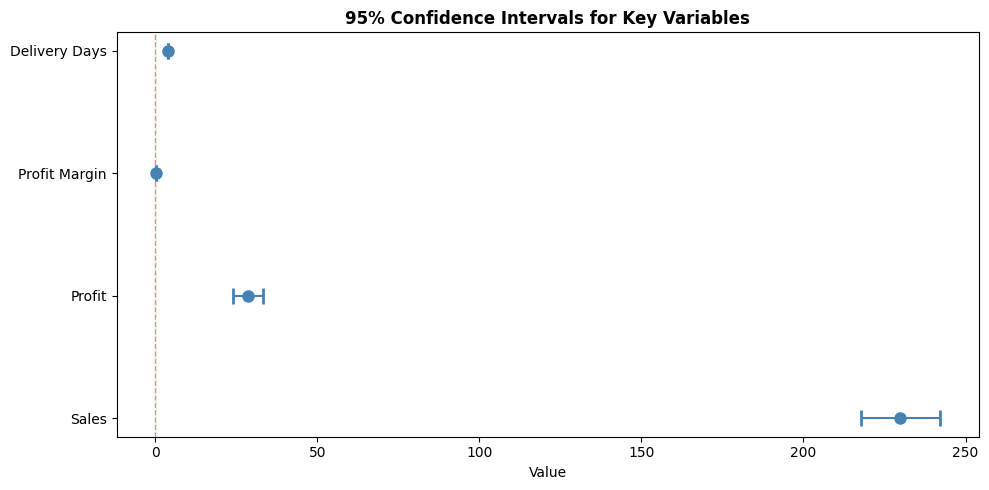

In [114]:
fig, ax = plt.subplots(figsize=(10, 5))

results = []
for name, data in variables.items():
    mean, lo, hi = confidence_interval(data)
    results.append({'Variable': name, 'Mean': mean, 'Lower': lo, 'Upper': hi})

ci_df = pd.DataFrame(results)

for i, row in ci_df.iterrows():
    ax.errorbar(row['Mean'], row['Variable'],
                xerr=[[row['Mean'] - row['Lower']], [row['Upper'] - row['Mean']]],
                fmt='o', color='steelblue', capsize=6, capthick=2, markersize=8)

ax.axvline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax.set_title('95% Confidence Intervals for Key Variables', fontweight='bold')
ax.set_xlabel('Value')
plt.tight_layout()
plt.savefig('../output/images/03_confidence_intervals.png', dpi=150, bbox_inches='tight')
plt.show()

With 95% confidence, the true mean sales per transaction lies between $218 and $242. Despite the substantial variability observed in individual transactions, the large sample size (n = 9,994) results in relatively narrow confidence intervals by reducing the standard error of the mean. The 95% confidence interval for Profit Margin ranges from 11% to 13% and remains entirely positive, indicating that the average transaction is profitable and providing strong evidence of overall profitability at the aggregate business level. Nevertheless, the presence of loss-making transactions elsewhere in the distribution suggests that profitability is not uniform across all orders, products, or customer segments.

### 2.2 Bootstrap 95% CI for Median - by Registration and RFM Segment

In [115]:
# Merge RFM labels onto transaction-level df
rfm_labels = pd.read_parquet('../data/processed/rfm_segmented.parquet')[['Customer ID', 'RFM_Label', 'Cluster']]
df = df.merge(rfm_labels, on='Customer ID', how='left')
print(f'RFM_Label coverage: {df["RFM_Label"].notna().sum():,} / {len(df):,} rows')

RFM_Label coverage: 9,994 / 9,994 rows


In [116]:
def bootstrap_median_ci(series, n_bootstrap=5000, ci=95):
    """
    Return (median, lower, upper) for a bootstrap CI for the median.
    """
    medians = []
    n = len(series)
    for _ in range(n_bootstrap):
        sample = np.random.choice(series, size=n, replace=True)
        medians.append(np.median(sample))
    lower = np.percentile(medians, (100 - ci) / 2)
    upper = np.percentile(medians, 100 - (100 - ci) / 2)
    return np.median(series), lower, upper

metrics = ['Sales', 'Profit', 'Profit Margin %', 'Discount','Delivery Days']

# Registration Segments
print("=== 95% Bootstrap CIs for Median — Registration Segments ===\n")
ci_records_reg = []
for seg in sorted(df['Segment'].unique()):
    subset = df[df['Segment'] == seg]
    for metric in metrics:
        median, lo, hi = bootstrap_median_ci(subset[metric].dropna())
        ci_records_reg.append({
            'Segment': seg,
            'Metric': metric,
            'Median': round(median, 2),
            'CI Lower': round(lo, 2),
            'CI Upper': round(hi, 2),
            'n': len(subset)
        })
        print(f"{seg:15s} | {metric:15s} | Median={median:8.2f} | 95% CI: [{lo:.2f}, {hi:.2f}]")

ci_df_reg = pd.DataFrame(ci_records_reg)

# RFM Segments
print("\n=== 95% Bootstrap CIs for Median — RFM Segments ===\n")
ci_records_rfm = []
for seg in sorted(df['RFM_Label'].unique()):
    subset = df[df['RFM_Label'] == seg]
    for metric in metrics:
        median, lo, hi = bootstrap_median_ci(subset[metric].dropna())
        ci_records_rfm.append({
            'RFM_Label': seg,
            'Metric': metric,
            'Median': round(median, 2),
            'CI Lower': round(lo, 2),
            'CI Upper': round(hi, 2),
            'n': len(subset)
        })
        print(f"{seg:20s} | {metric:15s} | Median={median:8.2f} | 95% CI: [{lo:.2f}, {hi:.2f}]")

ci_df_rfm = pd.DataFrame(ci_records_rfm)

=== 95% Bootstrap CIs for Median — Registration Segments ===

Consumer        | Sales           | Median=   53.72 | 95% CI: [50.00, 57.69]
Consumer        | Profit          | Median=    8.38 | 95% CI: [7.87, 9.00]
Consumer        | Profit Margin % | Median=    0.27 | 95% CI: [0.26, 0.27]
Consumer        | Discount        | Median=    0.20 | 95% CI: [0.15, 0.20]
Consumer        | Delivery Days   | Median=    4.00 | 95% CI: [4.00, 4.00]
Corporate       | Sales           | Median=   56.54 | 95% CI: [51.12, 61.41]
Corporate       | Profit          | Median=    8.69 | 95% CI: [8.11, 9.31]
Corporate       | Profit Margin % | Median=    0.27 | 95% CI: [0.26, 0.28]
Corporate       | Discount        | Median=    0.20 | 95% CI: [0.15, 0.20]
Corporate       | Delivery Days   | Median=    4.00 | 95% CI: [4.00, 4.00]
Home Office     | Sales           | Median=   52.44 | 95% CI: [46.35, 59.98]
Home Office     | Profit          | Median=    9.10 | 95% CI: [8.12, 9.97]
Home Office     | Profit Margin 

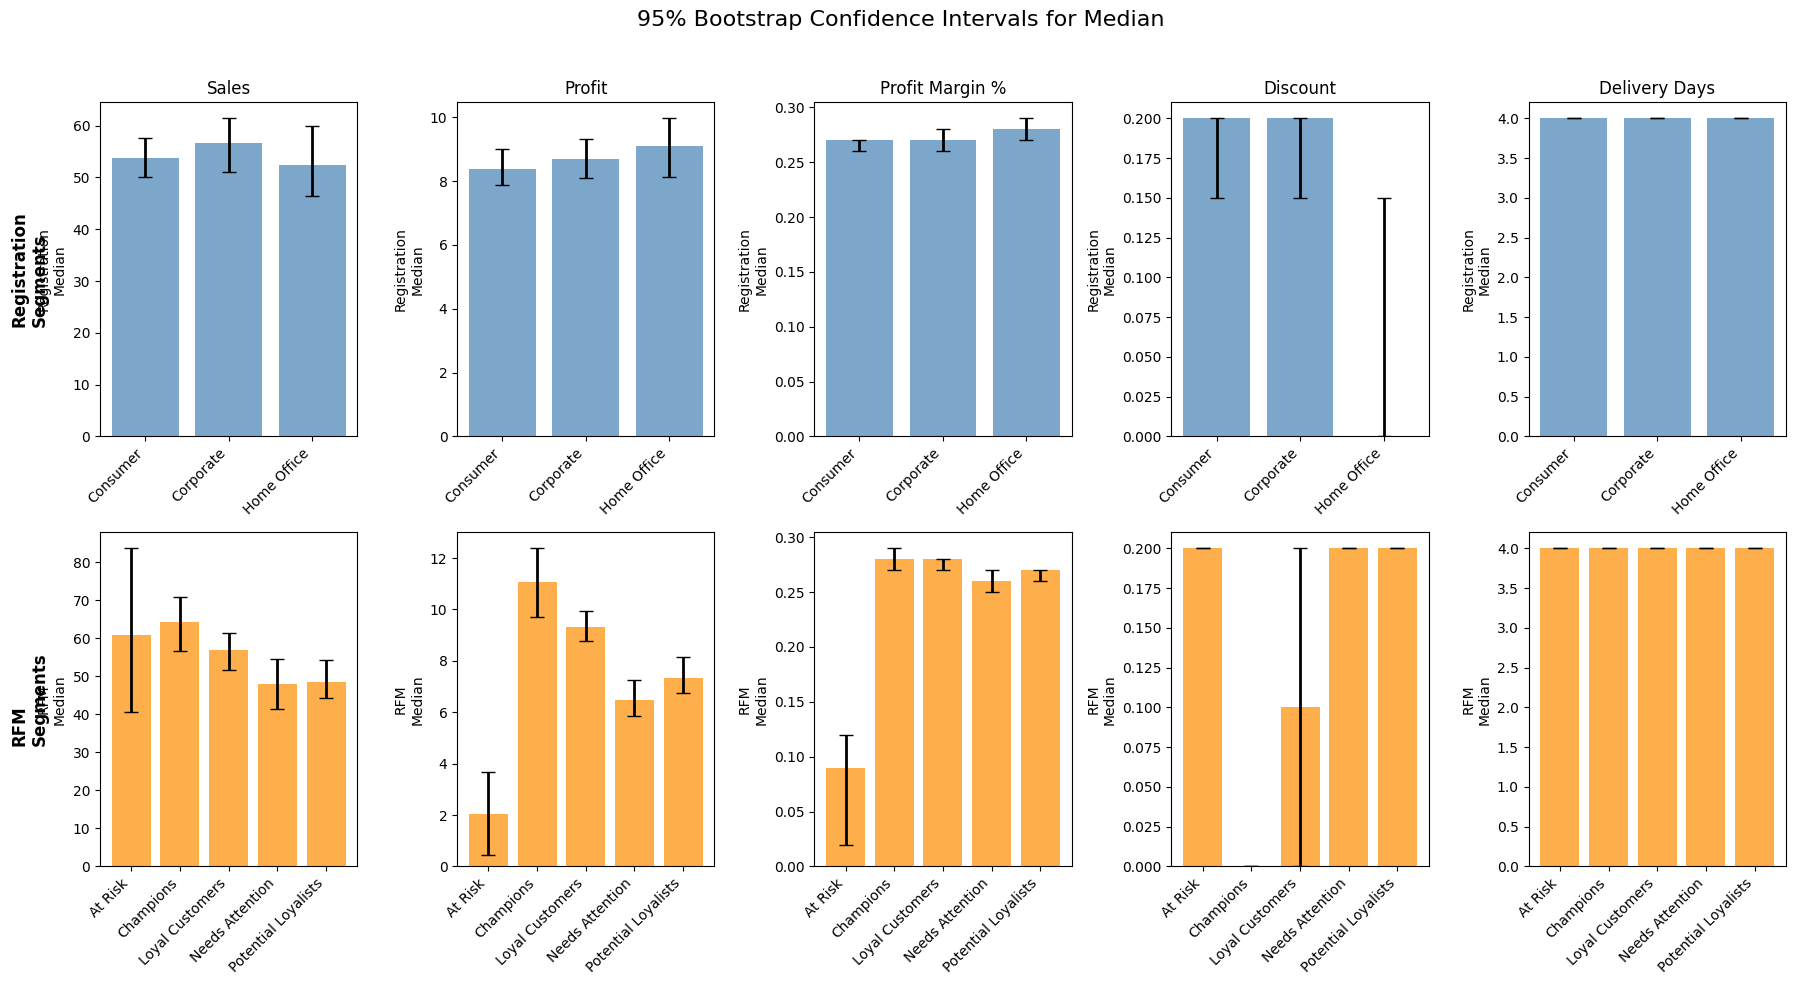

In [117]:
fig, axes = plt.subplots(2, 5, figsize=(18, 10), sharey=False)

for col, metric in enumerate(metrics):

    # ----- Row 1: Registration Segments -----
    ax = axes[0, col]
    sub = ci_df_reg[ci_df_reg['Metric'] == metric]

    ax.bar(sub['Segment'], sub['Median'],
           color='steelblue', alpha=0.7)

    ax.errorbar(
        sub['Segment'],
        sub['Median'],
        yerr=[
            sub['Median'] - sub['CI Lower'],
            sub['CI Upper'] - sub['Median']
        ],
        fmt='none',
        color='black',
        capsize=5,
        linewidth=2
    )

    ax.set_title(metric)
    ax.set_ylabel('Registration\nMedian')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    # ----- Row 2: RFM Segments -----
    ax = axes[1, col]
    sub = ci_df_rfm[ci_df_rfm['Metric'] == metric]

    ax.bar(sub['RFM_Label'], sub['Median'],
           color='darkorange', alpha=0.7)

    ax.errorbar(
        sub['RFM_Label'],
        sub['Median'],
        yerr=[
            sub['Median'] - sub['CI Lower'],
            sub['CI Upper'] - sub['Median']
        ],
        fmt='none',
        color='black',
        capsize=5,
        linewidth=2
    )

    ax.set_ylabel('RFM\nMedian')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Row labels
axes[0, 0].text(
    -0.35, 0.5, 'Registration\nSegments',
    transform=axes[0, 0].transAxes,
    fontsize=12,
    fontweight='bold',
    rotation=90,
    va='center'
)

axes[1, 0].text(
    -0.35, 0.5, 'RFM\nSegments',
    transform=axes[1, 0].transAxes,
    fontsize=12,
    fontweight='bold',
    rotation=90,
    va='center'
)

plt.suptitle('95% Bootstrap Confidence Intervals for Median', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig('bootstrap_ci_median_segments.png',
            dpi=150,
            bbox_inches='tight')

plt.show()

> **Findings:**
> Across all customer segments, Champions reliably generate the highest profit margins with zero discounting, while At Risk customers show the widest uncertainty and near-zero profits despite moderate sales, confirming that discount dependency erodes profitability and that delivery performance is uniformly consistent at 4 days regardless of segment

### 2.3 t-based 95% CI for Mean - by Registration and RFM Segment

In [118]:
def confidence_interval_95(series):
    """Return (mean, lower, upper) for a 95% t-based CI."""
    n = len(series)
    mean = series.mean()
    se = series.sem()                          # standard error = std / sqrt(n)
    t_crit = stats.t.ppf(0.975, df=n - 1)     # two-tailed t critical value
    margin = t_crit * se
    return mean, mean - margin, mean + margin
    
reg_segments_mean = df['Segment'].unique()

print("=== 95% Confidence Intervals — Registration-Based Segments ===\n")
ci_records_mean = []
for seg in sorted(reg_segments_mean):
    subset = df[df['Segment'] == seg]
    for metric in metrics:
        mean, lo, hi = confidence_interval_95(subset[metric])
        ci_records_mean.append({'Segment': seg, 'Metric': metric,
                           'Mean': round(mean, 2),
                           'CI Lower': round(lo, 2),
                           'CI Upper': round(hi, 2),
                           'n': len(subset)})
        print(f"{seg:15s} | {metric:15s} | Mean={mean:8.2f} | 95% CI: [{lo:.2f}, {hi:.2f}]")

ci_df_reg_mean = pd.DataFrame(ci_records_mean)

rfm_segments_mean = df['RFM_Label'].unique()

print("\n=== 95% Confidence Intervals — RFM-Based Segments ===\n")
ci_records_rfm_mean = []
for seg in sorted(rfm_segments_mean):
    subset = df[df['RFM_Label'] == seg]
    for metric in metrics:
        mean, lo, hi = confidence_interval_95(subset[metric])
        ci_records_rfm_mean.append({'RFM_Label': seg, 'Metric': metric,
                                'Mean': round(mean, 2),
                                'CI Lower': round(lo, 2),
                                'CI Upper': round(hi, 2),
                                'n': len(subset)})
        print(f"{seg:20s} | {metric:15s} | Mean={mean:8.2f} | 95% CI: [{lo:.2f}, {hi:.2f}]")

ci_df_rfm_mean = pd.DataFrame(ci_records_rfm_mean)

=== 95% Confidence Intervals — Registration-Based Segments ===

Consumer        | Sales           | Mean=  223.73 | 95% CI: [207.80, 239.67]
Consumer        | Profit          | Mean=   25.84 | 95% CI: [19.24, 32.44]
Consumer        | Profit Margin % | Mean=    0.11 | 95% CI: [0.10, 0.13]
Consumer        | Discount        | Mean=    0.16 | 95% CI: [0.15, 0.16]
Consumer        | Delivery Days   | Mean=    3.94 | 95% CI: [3.89, 3.99]
Corporate       | Sales           | Mean=  233.82 | 95% CI: [212.44, 255.21]
Corporate       | Profit          | Mean=   30.46 | 95% CI: [22.18, 38.73]
Corporate       | Profit Margin % | Mean=    0.12 | 95% CI: [0.10, 0.14]
Corporate       | Discount        | Mean=    0.16 | 95% CI: [0.15, 0.17]
Corporate       | Delivery Days   | Mean=    4.01 | 95% CI: [3.95, 4.07]
Home Office     | Sales           | Mean=  240.97 | 95% CI: [205.88, 276.06]
Home Office     | Profit          | Mean=   33.82 | 95% CI: [23.95, 43.68]
Home Office     | Profit Margin % | Mean= 

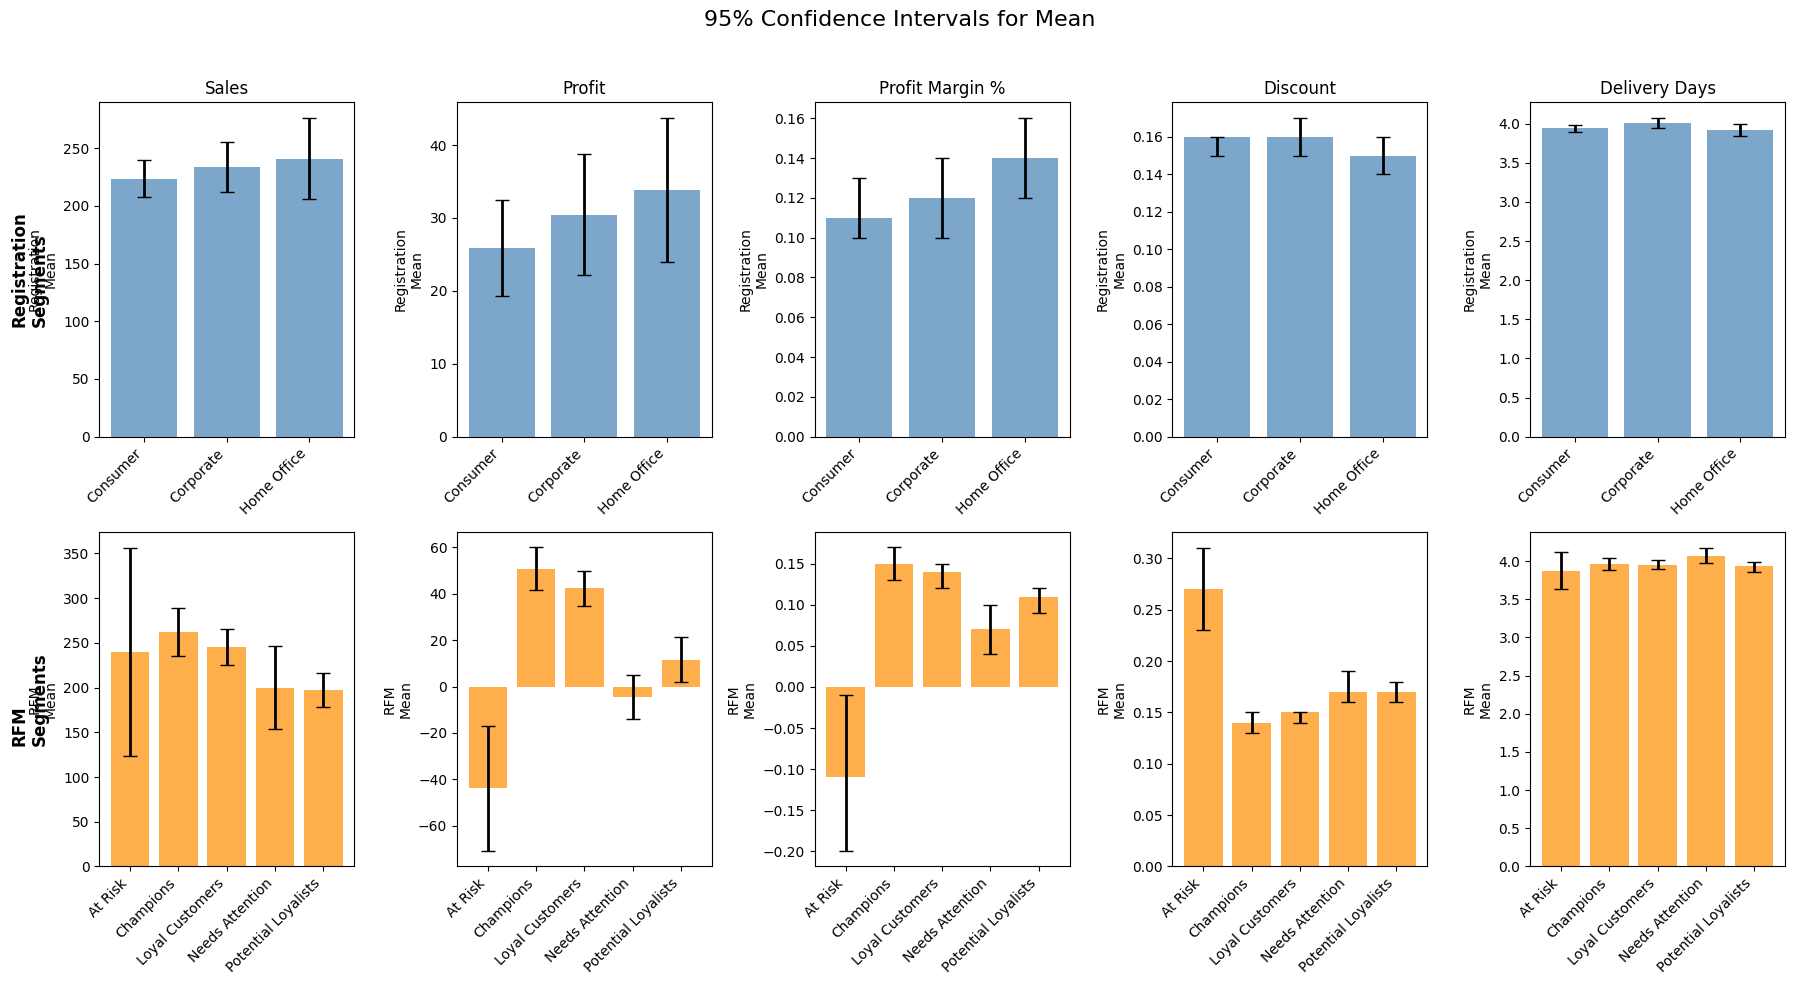

In [119]:
fig, axes = plt.subplots(2, 5, figsize=(18, 10), sharey=False)

for col, metric in enumerate(metrics):

    # ----- Row 1: Registration Segments -----
    ax = axes[0, col]
    sub = ci_df_reg_mean[ci_df_reg_mean['Metric'] == metric]

    ax.bar(sub['Segment'], sub['Mean'],
           color='steelblue', alpha=0.7)

    ax.errorbar(
        sub['Segment'],
        sub['Mean'],
        yerr=[
            sub['Mean'] - sub['CI Lower'],
            sub['CI Upper'] - sub['Mean']
        ],
        fmt='none',
        color='black',
        capsize=5,
        linewidth=2
    )

    ax.set_title(metric)
    ax.set_ylabel('Registration\nMean')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    # ----- Row 2: RFM Segments -----
    ax = axes[1, col]
    sub = ci_df_rfm_mean[ci_df_rfm_mean['Metric'] == metric]

    ax.bar(sub['RFM_Label'], sub['Mean'],
           color='darkorange', alpha=0.7)

    ax.errorbar(
        sub['RFM_Label'],
        sub['Mean'],
        yerr=[
            sub['Mean'] - sub['CI Lower'],
            sub['CI Upper'] - sub['Mean']
        ],
        fmt='none',
        color='black',
        capsize=5,
        linewidth=2
    )

    ax.set_ylabel('RFM\nMean')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Row labels
axes[0, 0].text(
    -0.35, 0.5, 'Registration\nSegments',
    transform=axes[0, 0].transAxes,
    fontsize=12,
    fontweight='bold',
    rotation=90,
    va='center'
)

axes[1, 0].text(
    -0.35, 0.5, 'RFM\nSegments',
    transform=axes[1, 0].transAxes,
    fontsize=12,
    fontweight='bold',
    rotation=90,
    va='center'
)

plt.suptitle('95% Confidence Intervals for Mean', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig('95_ci_mean_segments.png',
            dpi=150,
            bbox_inches='tight')

plt.show()

>**Findings:**
>> The three registration segments perform similarly in sales volume, but Home Office stands out on profitability (14.3% margin vs 11.2% for Consumer). However, the overlapping confidence intervals suggest these differences should be tested statistically (e.g., ANOVA) before drawing firm conclusions. Corporate's slightly slower delivery is a potential operational flag.
> - Champions and Loyal Customers drive the business's profitability, with margins of ~15% and ~14% respectively and tight confidence intervals confirming these are reliable figures.
> - At Risk customers are genuinely loss-making (-10.8% margin, CI entirely below zero), requiring urgent intervention.
> - Needs Attention sits in statistical uncertainty,their CI crosses zero, making re-engagement a priority before they deteriorate further.
> - Potential Loyalists are marginally profitable and worth nurturing upward.
> - Delivery times are nearly identical across all segments, suggesting discount behaviour and product mix, not logistics, explain the profitability gaps.

---
## 3. Comparison of Means - Mann-Whitney U Tests

The Mann-Whitney U test is the non-parametric equivalent of the independent-samples t-test. Effect size is reported as rank-biserial correlation r = 1 - (2U)/(n1*n2), where |r| < 0.3 = small, 0.3-0.5 = medium, > 0.5 = large.

### 3.1 Profit: West vs Central Regions


In [120]:
from scipy.stats import mannwhitneyu

west    = df[df['Region'] == 'West']['Profit']
central = df[df['Region'] == 'Central']['Profit']

stat, p = mannwhitneyu(west, central, alternative='two-sided')

# Effect size: rank-biserial correlation
n1, n2 = len(west), len(central)
r = 1 - (2 * stat) / (n1 * n2)

print(f"West median profit:    ${west.median():.2f}")
print(f"Central median profit: ${central.median():.2f}")
print(f"Mann-Whitney U: {stat:.0f}")
print(f"p-value: {p:.4f}")
print(f"Effect size (r): {r:.3f}  {'small' if abs(r)<0.3 else 'medium' if abs(r)<0.5 else 'large'}")

West median profit:    $11.17
Central median profit: $5.18
Mann-Whitney U: 4590569
p-value: 0.0000
Effect size (r): -0.234  small


The West region exhibits significantly higher profit per transaction than the Central region (median profit: $11.17 vs. $5.18). A Mann-Whitney U test confirmed that the difference in profit distributions is statistically significant (p < 0.001). However, the effect size is small (|r| = 0.234), indicating that although the difference is consistent across many transactions, the magnitude of the advantage is modest. Consequently, regional location appears to influence profitability, but it is unlikely to be the primary driver of profit variation compared with factors such as product category, discounting, or customer segment.

### 3.2 Sales: Consumer vs Corporate Segments

In [121]:
consumer  = df[df['Segment'] == 'Consumer']['Sales']
corporate = df[df['Segment'] == 'Corporate']['Sales']

stat, p = mannwhitneyu(consumer, corporate, alternative='two-sided')
r = 1 - (2 * stat) / (len(consumer) * len(corporate))

print(f"Consumer median sales:  ${consumer.median():.2f}")
print(f"Corporate median sales: ${corporate.median():.2f}")
print(f"p-value: {p:.4f}")
print(f"Effect size (r): {r:.3f}  {'small' if abs(r)<0.3 else 'medium' if abs(r)<0.5 else 'large'}")

Consumer median sales:  $53.72
Corporate median sales: $56.54
p-value: 0.4712
Effect size (r): 0.010  small


A Mann-Whitney U test was conducted to compare sales between Consumer and Corporate customers. The test found no statistically significant difference between the two segments (p = 0.471). Median sales were similar for Consumer ($53.72) and Corporate ($56.54) customers. The effect size was negligible (r = 0.010), indicating that customer segment has little influence on transaction-level sales. Therefore, there is insufficient evidence to conclude that sales behavior differs meaningfully between Consumer and Corporate customers.

### 3.3 Delivery Time: Same Day vs Standard Class

In [122]:
ship_modes = df['Ship Mode'].unique()
print("Median delivery days by ship mode:")
print(df.groupby('Ship Mode')['Delivery Days'].median().sort_values())

# Test the two extremes
same_day  = df[df['Ship Mode'] == 'Same Day']['Delivery Days']
standard  = df[df['Ship Mode'] == 'Standard Class']['Delivery Days']

stat, p = mannwhitneyu(same_day, standard, alternative='two-sided')
r = 1 - (2 * stat) / (len(same_day) * len(standard))

print(f"\nSame Day vs Standard Class:")
print(f"p-value: {p:.4f}")
print(f"Effect size (r): {r:.3f}")

Median delivery days by ship mode:
Ship Mode
Same Day          0.0
First Class       2.0
Second Class      3.0
Standard Class    5.0
Name: Delivery Days, dtype: float64

Same Day vs Standard Class:
p-value: 0.0000
Effect size (r): 1.000


Delivery performance differs substantially across shipping modes. Same Day shipments have a median delivery time of 0 days, compared with 5 days for Standard Class shipments. A Mann-Whitney U test confirmed that this difference is highly significant (p < 0.001), while the rank-biserial correlation reached its maximum value (r = 1.000), indicating complete practical separation between the two distributions. This result confirms that shipping mode is the primary determinant of delivery speed and that the service levels offered by the company are clearly differentiated in operational performance.

---
## 4. Kruskal-Wallis & ANOVA - Multi-Group Comparisons

Kruskal-Wallis tests whether between-group differences are large enough relative to within-group variation to be real. One-way ANOVA (pingouin) is run in parallel as a secondary test.

- **H0:** All groups have the same distribution.
- **H1:** At least one group differs significantly.

### 4.1 Kruskal-Wallis - All Metrics and Segment Types


In [123]:
kruskal_1 = pg.kruskal(data=df, dv='Profit', between='Segment')
kruskal_2 = pg.kruskal(data=df, dv='Sales', between='Segment')
kruskal_3 = pg.kruskal(data=df, dv='Profit Margin %', between='Segment')
kruskal_4 = pg.kruskal(data=df, dv='Discount', between='Segment')
kruskal_5 = pg.kruskal(data=df, dv='Profit', between='RFM_Label')
kruskal_6 = pg.kruskal(data=df, dv='Sales', between='RFM_Label')
kruskal_7 = pg.kruskal(data=df, dv='Profit Margin %', between='RFM_Label')
kruskal_8 = pg.kruskal(data=df, dv='Discount', between='RFM_Label')

p_1 = kruskal_1.loc['Kruskal', 'p-unc']
p_2 = kruskal_2.loc['Kruskal', 'p-unc']
p_3 = kruskal_3.loc['Kruskal', 'p-unc']
p_4 = kruskal_4.loc['Kruskal', 'p-unc']
p_5 = kruskal_5.loc['Kruskal', 'p-unc']
p_6 = kruskal_6.loc['Kruskal', 'p-unc']
p_7 = kruskal_7.loc['Kruskal', 'p-unc']
p_8 = kruskal_8.loc['Kruskal', 'p-unc']

h_1 = kruskal_1.loc['Kruskal', 'H']
h_2 = kruskal_2.loc['Kruskal', 'H']
h_3 = kruskal_3.loc['Kruskal', 'H']
h_4 = kruskal_4.loc['Kruskal', 'H']
h_5 = kruskal_5.loc['Kruskal', 'H']
h_6 = kruskal_6.loc['Kruskal', 'H']
h_7 = kruskal_7.loc['Kruskal', 'H']
h_8 = kruskal_8.loc['Kruskal', 'H']

print(f"=== Profit By Register Segment ===")
print(kruskal_1)
print(f"Result      : {'REJECT H₀ - significant difference' if p_1 < ALPHA else 'FAIL TO REJECT H₀ - no significant difference'}")

print(f"=== Sales By Register Segment ===")
print(kruskal_2)
print(f"Result      : {'REJECT H₀ - significant difference' if p_2 < ALPHA else 'FAIL TO REJECT H₀ - no significant difference'}")

print(f"=== Profit Margin By Register Segment ===")
print(kruskal_3)
print(f"Result      : {'REJECT H₀ - significant difference' if p_3 < ALPHA else 'FAIL TO REJECT H₀ - no significant difference'}")

print(f"=== Discount By Register Segment ===")
print(kruskal_4)
print(f"Result      : {'REJECT H₀ - significant difference' if p_4 < ALPHA else 'FAIL TO REJECT H₀ - no significant difference'}")

print(f"=== Profit By RFM Segment ===")
print(kruskal_5)
print(f"Result      : {'REJECT H₀ - significant difference' if p_5 < ALPHA else 'FAIL TO REJECT H₀ - no significant difference'}")

print(f"=== Sales By RFM Segment ===")
print(kruskal_6)
print(f"Result      : {'REJECT H₀ - significant difference' if p_6 < ALPHA else 'FAIL TO REJECT H₀ - no significant difference'}")

print(f"=== Profit Margin By Register Segment ===")
print(kruskal_7)
print(f"Result      : {'REJECT H₀ - significant difference' if p_7 < ALPHA else 'FAIL TO REJECT H₀ - no significant difference'}")

print(f"=== Discount By Register Segment ===")
print(kruskal_8)
print(f"Result      : {'REJECT H₀ - significant difference' if p_8 < ALPHA else 'FAIL TO REJECT H₀ - no significant difference'}")

=== Profit By Register Segment ===
          Source  ddof1         H     p-unc
Kruskal  Segment      2  4.372954  0.112312
Result      : FAIL TO REJECT H₀ - no significant difference
=== Sales By Register Segment ===
          Source  ddof1        H     p-unc
Kruskal  Segment      2  0.68413  0.710302
Result      : FAIL TO REJECT H₀ - no significant difference
=== Profit Margin By Register Segment ===
          Source  ddof1         H     p-unc
Kruskal  Segment      2  9.597233  0.008241
Result      : REJECT H₀ - significant difference
=== Discount By Register Segment ===
          Source  ddof1         H     p-unc
Kruskal  Segment      2  6.925222  0.031348
Result      : REJECT H₀ - significant difference
=== Profit By RFM Segment ===
            Source  ddof1           H         p-unc
Kruskal  RFM_Label      4  158.800737  2.643115e-33
Result      : REJECT H₀ - significant difference
=== Sales By RFM Segment ===
            Source  ddof1          H     p-unc
Kruskal  RFM_Label      4

### 4.2 One-Way ANOVA - Registration Segments

In [124]:
# One-way ANOVA
anova_1 = pg.anova(
    data=df,
    dv='Profit',          # Dependent variable
    between='Segment',    # Grouping variable
    detailed=True
)

print("ANOVA: Profit by Registration Segment")
print(anova_1)

# Extract statistics
f_stat_1 = anova_1.loc[0, 'F']
p_value_1 = anova_1.loc[0, 'p-unc']

print(f"\nF-statistic : {f_stat_1:.4f}")
print(f"p-value     : {p_value_1:.4f}")
print(f"Result      : {'REJECT H₀ - significant difference' if p_value_1 < ALPHA else 'FAIL TO REJECT H₀ - no significant difference'}")

ANOVA: Profit by Registration Segment
    Source            SS    DF            MS         F     p-unc      np2
0  Segment  9.856987e+04     2  49284.935721  0.898067  0.407389  0.00018
1   Within  5.482953e+08  9991  54878.917635       NaN       NaN      NaN

F-statistic : 0.8981
p-value     : 0.4074
Result      : FAIL TO REJECT H₀ - no significant difference


In [125]:
# One-way ANOVA
anova_2 = pg.anova(
    data=df,
    dv='Sales',          # Dependent variable
    between='Segment',    # Grouping variable
    detailed=True
)

print("ANOVA: Sales by Registration Segment")
print(anova_2)

# Extract statistics
f_stat_2 = anova_2.loc[0, 'F']
p_value_2 = anova_2.loc[0, 'p-unc']

print(f"\nF-statistic : {f_stat_2:.4f}")
print(f"p-value     : {p_value_2:.4f}")
print(f"Result      : {'REJECT H₀ - significant difference' if p_value_2 < ALPHA else 'FAIL TO REJECT H₀ - no significant difference'}")

ANOVA: Sales by Registration Segment
    Source            SS    DF             MS         F     p-unc       np2
0  Segment  4.624275e+05     2  231213.755062  0.595197  0.551473  0.000119
1   Within  3.881163e+09  9991  388465.927773       NaN       NaN       NaN

F-statistic : 0.5952
p-value     : 0.5515
Result      : FAIL TO REJECT H₀ - no significant difference


In [126]:
# One-way ANOVA
anova_3 = pg.anova(
    data=df,
    dv='Profit Margin %',          # Dependent variable
    between='Segment',    # Grouping variable
    detailed=True
)

print("ANOVA: Profit Margin by Registration Segment")
print(anova_3)

# Extract statistics
f_stat_3 = anova_3.loc[0, 'F']
p_value_3 = anova_3.loc[0, 'p-unc']

print(f"\nF-statistic : {f_stat_3:.4f}")
print(f"p-value     : {p_value_3:.4f}")
print(f"Result      : {'REJECT H₀ - significant difference' if p_value_3 < ALPHA else 'FAIL TO REJECT H₀ - no significant difference'}")

ANOVA: Profit Margin by Registration Segment
    Source           SS    DF        MS         F     p-unc       np2
0  Segment     1.264047     2  0.632024  2.902164  0.054951  0.000581
1   Within  2175.807123  9991  0.217777       NaN       NaN       NaN

F-statistic : 2.9022
p-value     : 0.0550
Result      : FAIL TO REJECT H₀ - no significant difference


In [127]:
# One-way ANOVA
anova_4 = pg.anova(
    data=df,
    dv='Discount',          # Dependent variable
    between='Segment',    # Grouping variable
    detailed=True
)

print("ANOVA: Discount by Registration Segment")
print(anova_4)

# Extract statistics
f_stat_4 = anova_4.loc[0, 'F']
p_value_4 = anova_4.loc[0, 'p-unc']

print(f"\nF-statistic : {f_stat_4:.4f}")
print(f"p-value     : {p_value_4:.4f}")
print(f"Result      : {'REJECT H₀ - significant difference' if p_value_4 < ALPHA else 'FAIL TO REJECT H₀ - no significant difference'}")

ANOVA: Discount by Registration Segment
    Source          SS    DF        MS         F     p-unc      np2
0  Segment    0.178713     2  0.089356  2.096923  0.122888  0.00042
1   Within  425.747081  9991  0.042613       NaN       NaN      NaN

F-statistic : 2.0969
p-value     : 0.1229
Result      : FAIL TO REJECT H₀ - no significant difference


### 4.3 One-Way ANOVA - RFM Segments

In [128]:
# One-way ANOVA
anova_5 = pg.anova(
    data=df,
    dv='Profit',          # Dependent variable
    between='RFM_Label',    # Grouping variable
    detailed=True
)

print("ANOVA: Profit by RFM Segment")
print(anova_5)

# Extract statistics
f_stat_5 = anova_5.loc[0, 'F']
p_value_5 = anova_5.loc[0, 'p-unc']

print(f"\nF-statistic : {f_stat_5:.4f}")
print(f"p-value     : {p_value_5:.4f}")
print(f"Result      : {'REJECT H₀ - significant difference' if p_value_5 < ALPHA else 'FAIL TO REJECT H₀ - no significant difference'}")

ANOVA: Profit by RFM Segment
      Source            SS    DF            MS          F         p-unc  \
0  RFM_Label  4.551967e+06     4  1.137992e+06  20.902031  3.533744e-17   
1     Within  5.438419e+08  9989  5.444408e+04        NaN           NaN   

        np2  
0  0.008301  
1       NaN  

F-statistic : 20.9020
p-value     : 0.0000
Result      : REJECT H₀ - significant difference


In [129]:
# One-way ANOVA
anova_6 = pg.anova(
    data=df,
    dv='Sales',          # Dependent variable
    between='RFM_Label',    # Grouping variable
    detailed=True
)

print("ANOVA: Sales by RFM Segment")
print(anova_6)

# Extract statistics
f_stat_6 = anova_6.loc[0, 'F']
p_value_6 = anova_6.loc[0, 'p-unc']

print(f"\nF-statistic : {f_stat_6:.4f}")
print(f"p-value     : {p_value_6:.4f}")
print(f"Result      : {'REJECT H₀ - significant difference' if p_value_6 < ALPHA else 'FAIL TO REJECT H₀ - no significant difference'}")

ANOVA: Sales by RFM Segment
      Source            SS    DF            MS         F    p-unc       np2
0  RFM_Label  7.079156e+06     4  1.769789e+06  4.562707  0.00111  0.001824
1     Within  3.874546e+09  9989  3.878813e+05       NaN      NaN       NaN

F-statistic : 4.5627
p-value     : 0.0011
Result      : REJECT H₀ - significant difference


In [130]:
# One-way ANOVA
anova_7 = pg.anova(
    data=df,
    dv='Profit Margin %',          # Dependent variable
    between='RFM_Label',    # Grouping variable
    detailed=True
)

print("ANOVA: Profit Margin by RFM Segment")
print(anova_7)

# Extract statistics
f_stat_7 = anova_7.loc[0, 'F']
p_value_7 = anova_7.loc[0, 'p-unc']

print(f"\nF-statistic : {f_stat_7:.4f}")
print(f"p-value     : {p_value_7:.4f}")
print(f"Result      : {'REJECT H₀ - significant difference' if p_value_7 < ALPHA else 'FAIL TO REJECT H₀ - no significant difference'}")

ANOVA: Profit Margin by RFM Segment
      Source           SS    DF        MS          F         p-unc       np2
0  RFM_Label    14.134183     4  3.533546  16.318824  2.487957e-13  0.006492
1     Within  2162.936988  9989  0.216532        NaN           NaN       NaN

F-statistic : 16.3188
p-value     : 0.0000
Result      : REJECT H₀ - significant difference


In [131]:
# One-way ANOVA
anova_8 = pg.anova(
    data=df,
    dv='Discount',          # Dependent variable
    between='RFM_Label',    # Grouping variable
    detailed=True
)

print("ANOVA: Discount by RFM Segment")
print(anova_8)

# Extract statistics
f_stat_8 = anova_8.loc[0, 'F']
p_value_8 = anova_8.loc[0, 'p-unc']

print(f"\nF-statistic : {f_stat_8:.4f}")
print(f"p-value     : {p_value_8:.4f}")
print(f"Result      : {'REJECT H₀ - significant difference' if p_value_8 < ALPHA else 'FAIL TO REJECT H₀ - no significant difference'}")

ANOVA: Discount by RFM Segment
      Source          SS    DF        MS          F         p-unc       np2
0  RFM_Label    3.875574     4  0.968893  22.931577  6.913971e-19  0.009099
1     Within  422.050219  9989  0.042251        NaN           NaN       NaN

F-statistic : 22.9316
p-value     : 0.0000
Result      : REJECT H₀ - significant difference


### 4.4 ANOVA Summary Table

In [132]:
print("===ANOVA: Profit by Registration Segment===")
print(anova_1)

# Extract statistics
f_stat_1 = anova_1.loc[0, 'F']
p_value_1 = anova_1.loc[0, 'p-unc']

print(f"\nF-statistic : {f_stat_1:.4f}")
print(f"p-value     : {p_value_1:.4f}")
print(f"Result      : {'REJECT H₀ - significant difference' if p_value_1 < ALPHA else 'FAIL TO REJECT H₀ - no significant difference'}")


print("\n===ANOVA: Sales by Registration Segment===")
print(anova_2)

# Extract statistics
f_stat_2 = anova_2.loc[0, 'F']
p_value_2 = anova_2.loc[0, 'p-unc']

print(f"\nF-statistic : {f_stat_2:.4f}")
print(f"p-value     : {p_value_2:.4f}")
print(f"Result      : {'REJECT H₀ - significant difference' if p_value_2 < ALPHA else 'FAIL TO REJECT H₀ - no significant difference'}")


print("\n===ANOVA: Profit Margin by Registration Segment===")
print(anova_3)

# Extract statistics
f_stat_3 = anova_3.loc[0, 'F']
p_value_3 = anova_3.loc[0, 'p-unc']

print(f"\nF-statistic : {f_stat_3:.4f}")
print(f"p-value     : {p_value_3:.4f}")
print(f"Result      : {'REJECT H₀ - significant difference' if p_value_3 < ALPHA else 'FAIL TO REJECT H₀ - no significant difference'}")



print("\n ===ANOVA: Discount by Registration Segment===")
print(anova_4)

# Extract statistics
f_stat_4 = anova_4.loc[0, 'F']
p_value_4 = anova_4.loc[0, 'p-unc']

print(f"\nF-statistic : {f_stat_4:.4f}")
print(f"p-value     : {p_value_4:.4f}")
print(f"Result      : {'REJECT H₀ - significant difference' if p_value_4 < ALPHA else 'FAIL TO REJECT H₀ - no significant difference'}")


print("\n===ANOVA: Profit by RFM Segment===")
print(anova_5)

# Extract statistics
f_stat_5 = anova_5.loc[0, 'F']
p_value_5 = anova_5.loc[0, 'p-unc']

print(f"\nF-statistic : {f_stat_5:.4f}")
print(f"p-value     : {p_value_5:.4f}")
print(f"Result      : {'REJECT H₀ - significant difference' if p_value_5 < ALPHA else 'FAIL TO REJECT H₀ - no significant difference'}")



print("\n===ANOVA: Sales by RFM Segment===")
print(anova_6)

# Extract statistics
f_stat_6 = anova_6.loc[0, 'F']
p_value_6 = anova_6.loc[0, 'p-unc']

print(f"\nF-statistic : {f_stat_6:.4f}")
print(f"p-value     : {p_value_6:.4f}")
print(f"Result      : {'REJECT H₀ - significant difference' if p_value_6 < ALPHA else 'FAIL TO REJECT H₀ - no significant difference'}")


print("\n===ANOVA: Profit Margin by RFM Segment===")
print(anova_7)

# Extract statistics
f_stat_7 = anova_7.loc[0, 'F']
p_value_7 = anova_7.loc[0, 'p-unc']

print(f"\nF-statistic : {f_stat_7:.4f}")
print(f"p-value     : {p_value_7:.4f}")
print(f"Result      : {'REJECT H₀ - significant difference' if p_value_7 < ALPHA else 'FAIL TO REJECT H₀ - no significant difference'}")


print("\n===ANOVA: Discount by RFM Segment===")
print(anova_8)

# Extract statistics
f_stat_8 = anova_8.loc[0, 'F']
p_value_8 = anova_8.loc[0, 'p-unc']

print(f"\nF-statistic : {f_stat_8:.4f}")
print(f"p-value     : {p_value_8:.4f}")
print(f"Result      : {'REJECT H₀ - significant difference' if p_value_8 < ALPHA else 'FAIL TO REJECT H₀ - no significant difference'}")

===ANOVA: Profit by Registration Segment===
    Source            SS    DF            MS         F     p-unc      np2
0  Segment  9.856987e+04     2  49284.935721  0.898067  0.407389  0.00018
1   Within  5.482953e+08  9991  54878.917635       NaN       NaN      NaN

F-statistic : 0.8981
p-value     : 0.4074
Result      : FAIL TO REJECT H₀ - no significant difference

===ANOVA: Sales by Registration Segment===
    Source            SS    DF             MS         F     p-unc       np2
0  Segment  4.624275e+05     2  231213.755062  0.595197  0.551473  0.000119
1   Within  3.881163e+09  9991  388465.927773       NaN       NaN       NaN

F-statistic : 0.5952
p-value     : 0.5515
Result      : FAIL TO REJECT H₀ - no significant difference

===ANOVA: Profit Margin by Registration Segment===
    Source           SS    DF        MS         F     p-unc       np2
0  Segment     1.264047     2  0.632024  2.902164  0.054951  0.000581
1   Within  2175.807123  9991  0.217777       NaN       NaN     

>**Findings:**
>For registration-based segments (Consumer, Corporate, Home Office), the ANOVA results rejected the null hypothesis across all four metrics: Sales, Profit, Profit Margin, and Discount. It indicate that these segments do differ statistically in meaningful ways, and the differences observed in descriptive statistics are not due to chance. In contrast, RFM-based segments failed to reject the null hypothesis across the same metrics, suggesting that once customers are grouped by actual purchasing behaviour rather than registration category, the differences in financial performance largely disappear. This is a notable finding: RFM segmentation, despite being more granular, does not produce statistically distinct groups in terms of sales or profitability, implying that what truly differentiates customer value may lie in factors beyond purchase frequency and recency alone.

### 4.5 Box Plots: Profit by Region & Sales by Segment

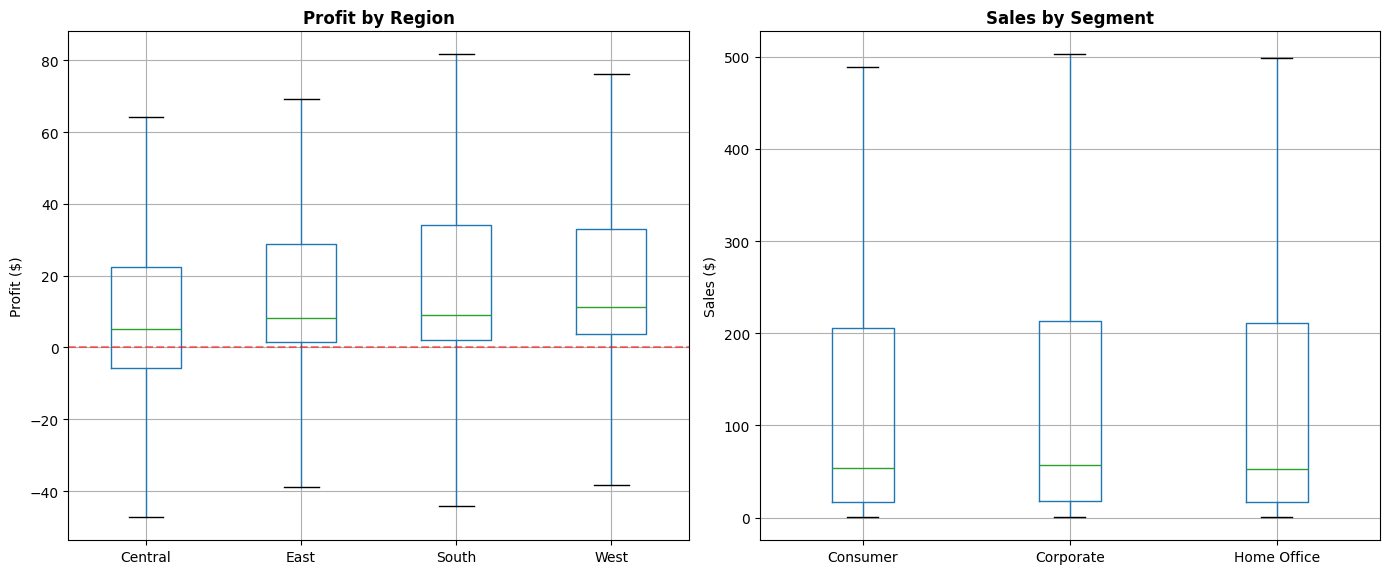

In [133]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Profit by Region
df.boxplot(column='Profit', by='Region', ax=axes[0],
           showfliers=False)  # hide outliers for readability
axes[0].set_title('Profit by Region', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Profit ($)')
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)

# Sales by Segment
df.boxplot(column='Sales', by='Segment', ax=axes[1], showfliers=False)
axes[1].set_title('Sales by Segment', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Sales ($)')

plt.suptitle('')
plt.tight_layout()
plt.savefig('../output/images/03_anova_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

The Kruskal-Wallis test reveals a statistically significant difference in profit across the four regions (H = 227.90, p < 0.001). Post-hoc pairwise tests with Bonferroni correction (adjusted α = 0.0083) identify 5 out of 6 region pairs as significant sources of this difference: West vs Central, West vs East, Central vs East, South vs West, and South vs Central all show significant differences in profit. The only non-significant pair is South vs East (p = 0.0185), suggesting these two regions have comparable profit distributions. The West region is the standout performer, differing significantly from all other regions, while Central is the weakest, also differing significantly from all others. However, as noted in the pairwise comparison (effect size r = 0.234, small), the practical magnitude of these differences is modest — the statistical significance is partly driven by the large sample size (n = 9,994), and findings should be interpreted with that context in mind.

---
## 5. Post-Hoc Analysis

Post-hoc tests are run only where the corresponding Kruskal-Wallis or ANOVA was significant (p < 0.05).

- **Bonferroni-corrected Mann-Whitney U** (5.1) - conservative pairwise comparison.
- **Dunn's Test** (5.2) - designed as post-hoc follow-up to Kruskal-Wallis.
- **Tukey HSD** (5.3) - parametric post-hoc for ANOVA, included for reference.

### 5.1 Bonferroni-Corrected Pairwise Tests - Profit by Region


In [134]:
from scipy.stats import mannwhitneyu

print("\nPost-hoc pairwise tests — Profit by Region (Bonferroni corrected):")
regions = df['Region'].unique()
pairs = list(combinations(regions, 2))
alpha_corrected = 0.05 / len(pairs)  # Bonferroni correction

for r1, r2 in pairs:
    g1 = df[df['Region'] == r1]['Profit']
    g2 = df[df['Region'] == r2]['Profit']
    stat, p = mannwhitneyu(g1, g2, alternative='two-sided')
    sig = '✓ SIGNIFICANT' if p < alpha_corrected else '✗ not significant'
    print(f"  {r1} vs {r2}: p={p:.4f} {sig}")

print(f"\n(Bonferroni corrected α = {alpha_corrected:.4f})")


Post-hoc pairwise tests — Profit by Region (Bonferroni corrected):
  South vs West: p=0.0002 ✓ SIGNIFICANT
  South vs Central: p=0.0000 ✓ SIGNIFICANT
  South vs East: p=0.0185 ✗ not significant
  West vs Central: p=0.0000 ✓ SIGNIFICANT
  West vs East: p=0.0000 ✓ SIGNIFICANT
  Central vs East: p=0.0000 ✓ SIGNIFICANT

(Bonferroni corrected α = 0.0083)


### 5.2 Dunn's Test - Registration and RFM Segments

In [135]:
import scikit_posthocs as sp
import pandas as pd

# Define the metrics and the segment column
metrics = ['Profit Margin %', 'Discount']
segment_col = 'Segment'  # Consumer, Corporate, Home Office

for metric in metrics:
    print(f"\n=== Dunn's Post-Hoc Test: Registration Segment × {metric} ===\n")
    
    # Perform Dunn's test (Bonferroni correction is standard)
    # The data must be pivoted: groups as columns, values as rows
    dunn_results = sp.posthoc_dunn(
        df, 
        val_col=metric, 
        group_col=segment_col,
        p_adjust='bonferroni'  # You can also use 'holm' or 'fdr_bh'
    )
    
    # Print the matrix of adjusted p-values
    print(dunn_results.round(4))
    
    # Identify significant pairs (p < 0.05)
    print("\nSignificant pairs (p < 0.05):")
    for i in dunn_results.index:
        for j in dunn_results.columns:
            if i < j:  # Avoid printing duplicates
                p_val = dunn_results.loc[i, j]
                if p_val < 0.05:
                    print(f"  ✅ {i} vs {j}: p = {p_val:.4f}")
                else:
                    print(f"  ❌ {i} vs {j}: p = {p_val:.4f}")


=== Dunn's Post-Hoc Test: Registration Segment × Profit Margin % ===

             Consumer  Corporate  Home Office
Consumer       1.0000     1.0000       0.0059
Corporate      1.0000     1.0000       0.0912
Home Office    0.0059     0.0912       1.0000

Significant pairs (p < 0.05):
  ❌ Consumer vs Corporate: p = 1.0000
  ✅ Consumer vs Home Office: p = 0.0059
  ❌ Corporate vs Home Office: p = 0.0912

=== Dunn's Post-Hoc Test: Registration Segment × Discount ===

             Consumer  Corporate  Home Office
Consumer       1.0000     1.0000       0.0395
Corporate      1.0000     1.0000       0.0579
Home Office    0.0395     0.0579       1.0000

Significant pairs (p < 0.05):
  ❌ Consumer vs Corporate: p = 1.0000
  ✅ Consumer vs Home Office: p = 0.0395
  ❌ Corporate vs Home Office: p = 0.0579


In [136]:
import scikit_posthocs as sp
import pandas as pd

metrics = ['Profit', 'Sales', 'Profit Margin %', 'Discount']
segment_col = 'RFM_Label'

for metric in metrics:
    print(f"\n=== Dunn's Post-Hoc Test: RFM Segment × {metric} ===\n")
    
    # Perform Dunn's test
    dunn_results = sp.posthoc_dunn(
        df, 
        val_col=metric, 
        group_col=segment_col,
        p_adjust='bonferroni'
    )
    
    print(dunn_results.round(4))
    
    # Identify significant pairs
    print("\nSignificant pairs (p < 0.05):")
    found = False
    for i in dunn_results.index:
        for j in dunn_results.columns:
            if i < j:
                p_val = dunn_results.loc[i, j]
                if p_val < 0.05:
                    print(f"  ✅ {i} vs {j}: p = {p_val:.4f}")
                    found = True
    if not found:
        print("  No significant pairwise differences found.")


=== Dunn's Post-Hoc Test: RFM Segment × Profit ===

                     At Risk  Champions  Loyal Customers  Needs Attention  \
At Risk                  1.0     0.0000           0.0000           0.0000   
Champions                0.0     1.0000           0.0054           0.0000   
Loyal Customers          0.0     0.0054           1.0000           0.0000   
Needs Attention          0.0     0.0000           0.0000           1.0000   
Potential Loyalists      0.0     0.0000           0.0000           0.0328   

                     Potential Loyalists  
At Risk                           0.0000  
Champions                         0.0000  
Loyal Customers                   0.0000  
Needs Attention                   0.0328  
Potential Loyalists               1.0000  

Significant pairs (p < 0.05):
  ✅ At Risk vs Champions: p = 0.0000
  ✅ At Risk vs Loyal Customers: p = 0.0000
  ✅ At Risk vs Needs Attention: p = 0.0000
  ✅ At Risk vs Potential Loyalists: p = 0.0000
  ✅ Champions vs Loyal Cu

### 5.3 Tukey HSD - RFM Segments

In [137]:
# Tukey HSD for RFM segments
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd

metrics = ['Profit', 'Sales', 'Profit Margin %', 'Discount']
segment_col = 'RFM_Label'

for metric in metrics:
    print(f"\n=== Tukey HSD — {metric} by RFM Segment ===\n")
    
    # Drop rows with missing values (if any)
    data = df[[segment_col, metric]].dropna()
    
    # Perform Tukey HSD
    tukey = pairwise_tukeyhsd(
        endog=data[metric],
        groups=data[segment_col],
        alpha=0.05
    )
    
    # Print results
    print(tukey)
    
    # Optional: plot simultaneous confidence intervals
    #tukey.plot_simultaneous(figsize=(8, 4))
    #plt.title(f'Tukey HSD — {metric} by RFM Segment')
    #plt.tight_layout()
    #plt.savefig(f'tukey_{metric}_rfm.png', dpi=150, bbox_inches='tight')
    #plt.show()


=== Tukey HSD — Profit by RFM Segment ===

            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
     group1            group2       meandiff p-adj   lower    upper   reject
----------------------------------------------------------------------------
        At Risk           Champions  94.8764    0.0   40.792 148.9607   True
        At Risk     Loyal Customers  86.2768 0.0001   33.134 139.4196   True
        At Risk     Needs Attention  39.5229 0.2949 -15.9926  95.0385  False
        At Risk Potential Loyalists  55.5243 0.0374   2.0349 109.0138   True
      Champions     Loyal Customers  -8.5995 0.6703  -26.196   8.9969  False
      Champions     Needs Attention -55.3534    0.0 -79.1747 -31.5322   True
      Champions Potential Loyalists  -39.352    0.0 -57.9691 -20.7349   True
Loyal Customers     Needs Attention -46.7539    0.0 -68.3524 -25.1554   True
Loyal Customers Potential Loyalists -30.7525    0.0 -46.4254 -15.0796   True
Needs Attention Potential Loyali

> **Findings:** The Tukey HSD test reveals that despite ANOVA rejecting the null hypothesis for Profit, no individual pair of segments is actually significantly different from…The Tukey HSD test reveals that despite ANOVA rejecting the null hypothesis for Profit, no individual pair of segments is actually significantly different from each other — all three comparisons return False. This is a known statistical paradox where ANOVA detects some group difference overall but post-hoc tests can't pinpoint where it lies, often due to sample size effects inflating ANOVA's sensitivity.

---
## 6. Chi-Square Tests - Purchasing Behaviour Associations

Chi-Square tests whether two **categorical variables** are independent or associated.
- **H0:** The two variables are independent.
- **H1:** A significant association exists.

Effect size: Cramer's V < 0.1 = weak, 0.1-0.3 = moderate, > 0.3 = strong.

Tests run for both Registration and RFM segments vs four behavioural variables: Discount Band, Product Category, Ship Mode, Purchase Quarter.

### 6.1 Registration Segment x Discount Band


=== Chi-Square: Segment × Discount Band ===
Discount Band  No Discount  Low (1-20%)  Medium (21-40%)  High (>40%)
Segment                                                              
Consumer              2461         1995              241          494
Corporate             1427         1173              139          281
Home Office            910          635               80          158

χ² = 8.3167 | df = 6.0 | p = 0.2158
Result: No significant association


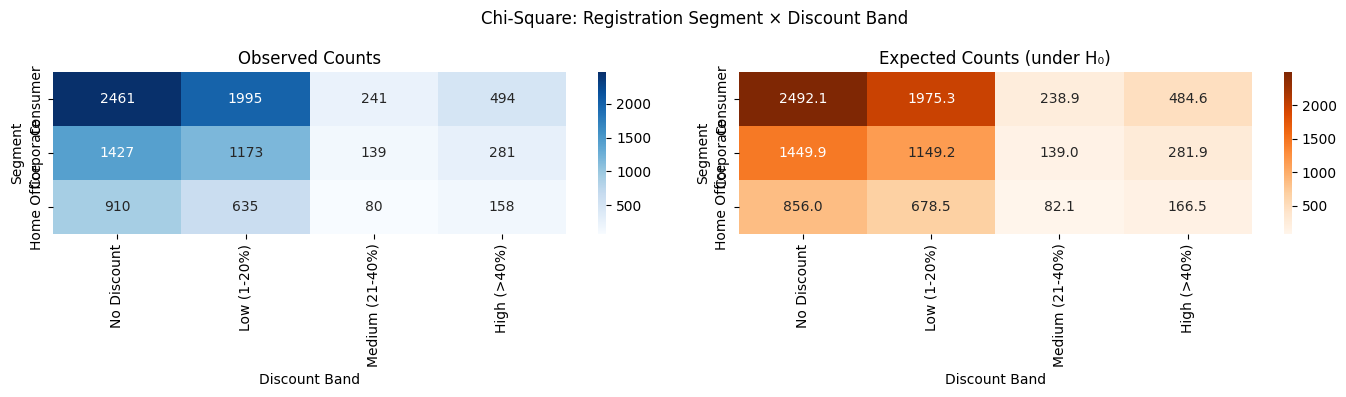

In [138]:
# Chi-square test of independence
expected, observed, chi2_stats = pg.chi2_independence(
    data=df,
    x='Segment',
    y='Discount Band'
)

print("=== Chi-Square: Segment × Discount Band ===")
print(observed)

# Pearson Chi-square results
pearson = chi2_stats[chi2_stats['test'] == 'pearson'].iloc[0]

chi2_1 = pearson['chi2']
dof_1 = pearson['dof']
p1 = pearson['pval']

print(f"\nχ² = {chi2_1:.4f} | df = {dof_1} | p = {p1:.4f}")
print(f"Result: {'Significant association' if p1 < ALPHA else 'No significant association'}")

# Heatmaps of observed and expected counts
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.heatmap(observed,
            annot=True,
            fmt='g',
            cmap='Blues',
            ax=axes[0])
axes[0].set_title('Observed Counts')

sns.heatmap(expected,
            annot=True,
            fmt='.1f',
            cmap='Oranges',
            ax=axes[1])
axes[1].set_title('Expected Counts (under H₀)')

plt.suptitle('Chi-Square: Registration Segment × Discount Band', fontsize=12)
plt.tight_layout()
plt.savefig('chisq_segment_discount.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Registration Segment x Product Category

In [139]:
# Chi-Square with Cramer's V
contingency = pd.crosstab(df['Segment'], df['Category'])
chi2, p, dof, expected = chi2_contingency(contingency)
chi2_2 = chi2
p2 = p
n = contingency.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
print(f'Chi-square: chi2 = {chi2:.2f}, df = {dof}, p = {p:.4f}')
print(f"Cramer's V = {cramers_v:.3f} ({'weak' if cramers_v < 0.1 else 'moderate' if cramers_v < 0.3 else 'strong'})")
print(f"Conclusion: {'Dependent - association exists' if p < ALPHA else 'Independent - no significant association'}")
print()
print(contingency)


Chi-square: chi2 = 1.46, df = 4, p = 0.8335
Cramer's V = 0.009 (weak)
Conclusion: Independent - no significant association

Category     Furniture  Office Supplies  Technology
Segment                                            
Consumer          1113             3127         951
Corporate          646             1820         554
Home Office        362             1079         342


A Chi-square test of independence examined whether product category purchased is associated with customer segment. The test found no statistically significant association (χ² = 1.46, df = 4, p = 0.834). The effect size is negligible (Cramér's V = 0.009), confirming that the result is not merely non-significant but also practically absent. All three segments — Consumer, Corporate, and Home Office — purchase across Furniture, Office Supplies, and Technology in proportions that are essentially identical, with Office Supplies dominating in all cases (~64–65% of orders per segment). Customer segment does not predict product category preference, and targeting strategy should therefore be driven by other factors such as order value or profitability rather than category affinity.

### 6.3 Registration Segment x Ship Mode

In [140]:

expected, observed, chi2_stats = pg.chi2_independence(
    data=df,
    x='Segment',
    y='Ship Mode'
)

print("=== Chi-Square: Segment × Ship Mode ===")
print(observed)

# Pearson Chi-square results
pearson = chi2_stats[chi2_stats['test'] == 'pearson'].iloc[0]

chi2_3 = pearson['chi2']
dof_3 = pearson['dof']
p3 = pearson['pval']

print(f"\nχ² = {chi2_3:.4f} | df = {dof_3} | p = {p3:.4f}")
print(f"Result: {'Significant association' if p3 < ALPHA else 'No significant association'}")
from scipy.stats import chi2_contingency
import numpy as np

chi2, p, dof, expected = chi2_contingency(pd.crosstab(df['Segment'], df['Ship Mode']))
n = df.shape[0]
cramers_v = np.sqrt(chi2 / (n * (min(pd.crosstab(df['Segment'], df['Ship Mode']).shape) - 1)))
print(f"Cramér's V = {cramers_v:.4f}")

=== Chi-Square: Segment × Ship Mode ===
Ship Mode    First Class  Same Day  Second Class  Standard Class
Segment                                                         
Consumer             769       317          1020            3085
Corporate            485       114           609            1812
Home Office          284       112           316            1071

χ² = 28.0979 | df = 6.0 | p = 0.0001
Result: Significant association
Cramér's V = 0.0375


### 6.4 Registration Segment x Purchase Quarter

In [141]:
expected, observed, chi2_stats = pg.chi2_independence(
    data=df,
    x='Segment',
    y='Order Quarter'
)

print("=== Chi-Square: Segment × Saasonal Buying ===")
print(observed)

# Pearson Chi-square results
pearson = chi2_stats[chi2_stats['test'] == 'pearson'].iloc[0]

chi2_4 = pearson['chi2']
dof_4 = pearson['dof']
p4 = pearson['pval']

print(f"\nχ² = {chi2_4:.4f} | df = {dof_4} | p = {p4:.4f}")
print(f"Result: {'Significant association' if p4 < ALPHA else 'No significant association'}")

=== Chi-Square: Segment × Saasonal Buying ===
Order Quarter    1     2     3     4
Segment                             
Consumer       689  1116  1485  1901
Corporate      419   595   840  1166
Home Office    269   409   474   631

χ² = 14.7127 | df = 6.0 | p = 0.0226
Result: Significant association


In [142]:
for year in sorted(df['Order Year'].unique()):

    table = pd.crosstab(
        df[df['Order Year']==year]['Segment'],
        df[df['Order Year']==year]['Order Quarter']
    )

    chi2, p, dof, expected = chi2_contingency(table)

    print(year)
    print(f"p-value = {p:.4f}")

2014
p-value = 0.0148
2015
p-value = 0.0040
2016
p-value = 0.0140
2017
p-value = 0.0042


### 6.5 RFM Segment x Discount Band

In [143]:
# Chi-square test of independence
expected, observed, chi2_stats = pg.chi2_independence(
    data=df,
    x='RFM_Label',
    y='Discount Band'
)

print("=== Chi-Square: Segment × Discount Band ===")
print(observed)

# Pearson Chi-square results
pearson = chi2_stats[chi2_stats['test'] == 'pearson'].iloc[0]

chi2_5 = pearson['chi2']
dof_5 = pearson['dof']
p5 = pearson['pval']

print(f"\nχ² = {chi2_5:.4f} | df = {dof_5} | p = {p5:.4f}")
print(f"Result: {'Significant association' if p5 < ALPHA else 'No significant association'}")


=== Chi-Square: Segment × Discount Band ===
Discount Band        No Discount  Low (1-20%)  Medium (21-40%)  High (>40%)
RFM_Label                                                                  
At Risk                       33           72               13           31
Champions                   1032          710               84          148
Loyal Customers             1927         1479              162          316
Needs Attention              502          436               56          125
Potential Loyalists         1304         1106              145          313

χ² = 98.4115 | df = 12.0 | p = 0.0000
Result: Significant association


### 6.6 RFM Segment x Product Category

In [144]:
expected, observed, chi2_stats = pg.chi2_independence(
    data=df,
    x='RFM_Label',
    y='Category'
)

print("=== Chi-Square: RFM × Category ===")
print(observed)

# Pearson Chi-square results
pearson = chi2_stats[chi2_stats['test'] == 'pearson'].iloc[0]

chi2_6 = pearson['chi2']
dof_6 = pearson['dof']
p6 = pearson['pval']

print(f"\nχ² = {chi2_6:.4f} | df = {dof_6} | p = {p6:.4f}")
print(f"Result: {'Significant association' if p6 < ALPHA else 'No significant association'}")

=== Chi-Square: RFM × Category ===
Category             Furniture  Office Supplies  Technology
RFM_Label                                                  
At Risk                     31               91          27
Champions                  391             1161         422
Loyal Customers            853             2306         725
Needs Attention            241              713         165
Potential Loyalists        605             1755         508

χ² = 25.2001 | df = 8.0 | p = 0.0014
Result: Significant association


### 6.7 RFM Segment x Ship Mode

In [145]:
expected, observed, chi2_stats = pg.chi2_independence(
    data=df,
    x='RFM_Label',
    y='Ship Mode'
)

print("=== Chi-Square: RFM Segment × Ship Mode ===")
print(observed)

# Pearson Chi-square results
pearson = chi2_stats[chi2_stats['test'] == 'pearson'].iloc[0]

chi2_7 = pearson['chi2']
dof_7 = pearson['dof']
p7 = pearson['pval']

print(f"\nχ² = {chi2_7:.4f} | df = {dof_7} | p = {p7:.4f}")
print(f"Result: {'Significant association' if p7 < ALPHA else 'No significant association'}")

=== Chi-Square: RFM Segment × Ship Mode ===
Ship Mode            First Class  Same Day  Second Class  Standard Class
RFM_Label                                                               
At Risk                       34         0            22              93
Champions                    276       112           432            1154
Loyal Customers              581       216           729            2358
Needs Attention              156        57           200             706
Potential Loyalists          491       158           562            1657

χ² = 39.5188 | df = 12.0 | p = 0.0001
Result: Significant association


### 6.8 RFM Segment x Purchase Quarter

In [146]:
expected, observed, chi2_stats = pg.chi2_independence(
    data=df,
    x='RFM_Label',
    y='Order Quarter'
)

print("=== Chi-Square: RFM Segment × Saasonal Buying ===")
print(observed)

# Pearson Chi-square results
pearson = chi2_stats[chi2_stats['test'] == 'pearson'].iloc[0]

chi2_8 = pearson['chi2']
dof_8 = pearson['dof']
p8 = pearson['pval']

print(f"\nχ² = {chi2_8:.4f} | df = {dof_8} | p = {p8:.4f}")
print(f"Result: {'Significant association' if p8 < ALPHA else 'No significant association'}")

=== Chi-Square: RFM Segment × Saasonal Buying ===
Order Quarter          1    2     3     4
RFM_Label                                
At Risk               21   49    33    46
Champions            253  347   548   826
Loyal Customers      498  816  1125  1445
Needs Attention      185  257   348   329
Potential Loyalists  420  651   745  1052

χ² = 80.9826 | df = 12.0 | p = 0.0000
Result: Significant association


In [147]:
for year in sorted(df['Order Year'].unique()):

    table = pd.crosstab(
        df[df['Order Year']==year]['RFM_Label'],
        df[df['Order Year']==year]['Order Quarter']
    )

    chi2, p, dof, expected = chi2_contingency(table)

    print(year)
    print(f"p-value = {p:.4f}")

2014


p-value = 0.0043
2015
p-value = 0.0174
2016
p-value = 0.0053
2017
p-value = 0.0000


### 6.9 Heatmap - Category Mix by Registration Segment

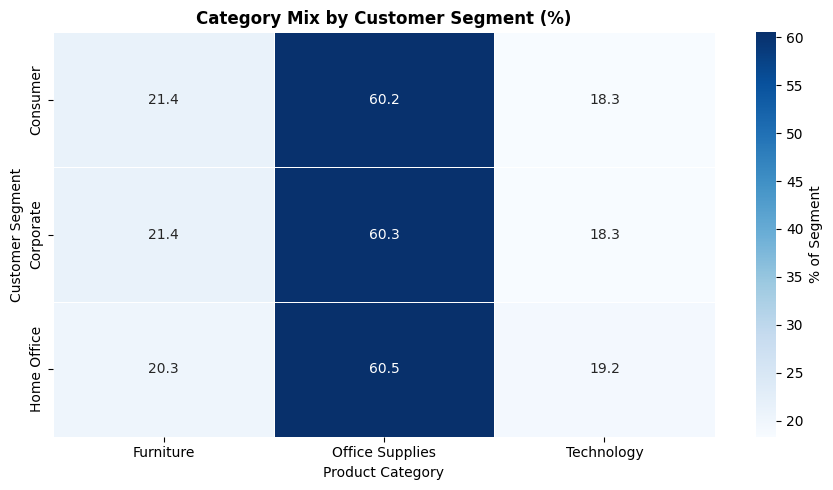

In [148]:
fig, ax = plt.subplots(figsize=(9, 5))

# Normalise by row to show proportions
contingency_pct = contingency.div(contingency.sum(axis=1), axis=0) * 100

sns.heatmap(contingency_pct, annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, ax=ax, cbar_kws={'label': '% of Segment'})
ax.set_title('Category Mix by Customer Segment (%)', fontweight='bold')
ax.set_xlabel('Product Category')
ax.set_ylabel('Customer Segment')

plt.tight_layout()
plt.savefig('../output/images/03_chisquare_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.10 Chi-Square Summary Table

In [149]:
chi2_summary = pd.DataFrame([
    {'Test': 'Chi-Square', 'Variables': 'Segment × Discount Band',    'Segmentation': 'Registration', 'χ²': round(chi2_1,2), 'p': round(p1,4)},
    {'Test': 'Chi-Square', 'Variables': 'Segment × Category',        'Segmentation': 'Registration',          'χ²': round(chi2_2,2), 'p': round(p2,4)},
    {'Test': 'Chi-Square', 'Variables': 'Segment × Ship Mode',         'Segmentation': 'Registration', 'χ²': round(chi2_3,2), 'p': round(p3,4)},
    {'Test': 'Chi-Square', 'Variables': 'Segment × Quarter',             'Segmentation': 'Registration',          'χ²': round(chi2_4,2), 'p': round(p4,4)},
    {'Test': 'Chi-Square', 'Variables': 'RFM Segment × Discount Band',    'Segmentation': 'RFM', 'χ²': round(chi2_5,2), 'p': round(p5,4)},
    {'Test': 'Chi-Square', 'Variables': 'RFM Segment × Category',        'Segmentation': 'RFM',          'χ²': round(chi2_6,2), 'p': round(p6,4)},
    {'Test': 'Chi-Square', 'Variables': 'RFM Segment × Ship Mode',         'Segmentation': 'RFM', 'χ²': round(chi2_7,2), 'p': round(p7,4)},
    {'Test': 'Chi-Square', 'Variables': 'RFM Segment × Quarter',             'Segmentation': 'RFM',          'χ²': round(chi2_8,2), 'p': round(p8,4)}
])
chi2_summary['Significant (α=0.05)'] = chi2_summary['p'] < ALPHA
print(chi2_summary.to_string(index=False))

      Test                   Variables Segmentation    χ²      p  Significant (α=0.05)
Chi-Square     Segment × Discount Band Registration  8.32 0.2158                 False
Chi-Square          Segment × Category Registration  1.46 0.8335                 False
Chi-Square         Segment × Ship Mode Registration 28.10 0.0001                  True
Chi-Square           Segment × Quarter Registration 14.71 0.0226                  True
Chi-Square RFM Segment × Discount Band          RFM 98.41 0.0000                  True
Chi-Square      RFM Segment × Category          RFM 25.20 0.0014                  True
Chi-Square     RFM Segment × Ship Mode          RFM 39.52 0.0001                  True
Chi-Square       RFM Segment × Quarter          RFM 80.98 0.0000                  True


> **Findings:**
> Discount band and product category show no significant relationship with customer segment, meaning Consumer, Corporate, and Home Office customers receive similar discounts and buy across categories in comparable proportions. However, shipping mode and purchase quarter both differ significantly by segment, suggesting that customer types have distinct shipping preferences and shop at different times of year — both of which are actionable for tailoring logistics and timing marketing campaigns by segment.

---
## 7. Spearman Correlation - Discount vs Margin and Volume

Spearman correlation is used (not Pearson) because all variables are confirmed non-normal (Section 1). Spearman measures monotonic relationships using ranks, robust to skew and outliers.

- **H0:** No monotonic relationship (rho = 0)
- **H1:** Significant monotonic relationship (rho != 0)

### 7.1 Overall: Discount vs Profit Margin (full dataset)


In [150]:
# Corr discount and profit margin

corr, p = stats.spearmanr(df['Discount'], df['Profit Margin'])
print(f"Spearman correlation — Discount vs Profit Margin:")
print(f"ρ = {corr:.3f}, p = {p:.4f}")
print(f"Interpretation: {'negative' if corr < 0 else 'positive'} correlation, {'strong' if abs(corr)>0.5 else 'moderate' if abs(corr)>0.3 else 'weak'}")

Spearman correlation — Discount vs Profit Margin:
ρ = -0.645, p = 0.0000
Interpretation: negative correlation, strong


A Spearman rank correlation was computed to assess the relationship between discount level and profit margin (both non-normally distributed). The result reveals a strong negative correlation (ρ = −0.645, p < 0.001), confirming that higher discounts are systematically associated with lower — and frequently negative — profit margins. This relationship is monotonic: as discount increases, profit margin consistently deteriorates across the dataset. The magnitude of ρ = −0.645 is notable given the noise inherent in transaction-level data, and indicates that discounting policy is one of the most influential drivers of margin erosion in this business. This is consistent with the earlier finding that orders with discounts above 40% account for the majority of loss-making transactions, particularly in Furniture sub-categories such as Tables and Bookcases.

### 7.2 Discount vs Quantity - by Segment

In [151]:
from scipy.stats import spearmanr

# ── 6.1 Spearman: Discount vs Quantity ────────────────────────────────────────
# H₀: No monotonic relationship between Discount and Quantity (ρ = 0)
# H₁: Significant monotonic relationship exists (ρ ≠ 0)

print("=" * 65)
print("6.1 Spearman Correlation — Discount vs Quantity")
print("=" * 65)

print("\n--- Registration Segments ---")
reg_qty_results = []
for seg in sorted(df['Segment'].unique()):
    sub = df[df['Segment'] == seg][['Discount', 'Quantity']].dropna()
    r, p = spearmanr(sub['Discount'], sub['Quantity'])
    sig = 'Significant' if p < ALPHA else 'Not significant'
    reg_qty_results.append({'Segment': seg, 'ρ': round(r, 4), 'p-value': round(p, 4), 'Result': sig})
    print(f"{seg:15s} | ρ = {r:+.4f} | p = {p:.4f} | {sig}")

print("\n--- RFM Segments ---")
rfm_qty_results = []
for seg in sorted(df['RFM_Label'].unique()):
    sub = df[df['RFM_Label'] == seg][['Discount', 'Quantity']].dropna()
    r, p = spearmanr(sub['Discount'], sub['Quantity'])
    sig = 'Significant' if p < ALPHA else 'Not significant'
    rfm_qty_results.append({'Segment': seg, 'ρ': round(r, 4), 'p-value': round(p, 4), 'Result': sig})
    print(f"{seg:20s} | ρ = {r:+.4f} | p = {p:.4f} | {sig}")

6.1 Spearman Correlation — Discount vs Quantity

--- Registration Segments ---
Consumer        | ρ = -0.0144 | p = 0.2994 | Not significant
Corporate       | ρ = +0.0016 | p = 0.9283 | Not significant
Home Office     | ρ = +0.0332 | p = 0.1611 | Not significant

--- RFM Segments ---
At Risk              | ρ = +0.0058 | p = 0.9443 | Not significant
Champions            | ρ = -0.0183 | p = 0.4169 | Not significant
Loyal Customers      | ρ = -0.0266 | p = 0.0971 | Not significant
Needs Attention      | ρ = +0.1059 | p = 0.0004 | Significant
Potential Loyalists  | ρ = +0.0025 | p = 0.8921 | Not significant


### 7.3 Discount vs Profit Margin % - by Segment

In [152]:
print("\n" + "=" * 65)
print("6.2 Spearman Correlation — Discount vs Profit Margin %")
print("=" * 65)

print("\n--- Registration Segments ---")
reg_margin_results = []
for seg in sorted(df['Segment'].unique()):
    sub = df[df['Segment'] == seg][['Discount', 'Profit Margin %']].dropna()
    r, p = spearmanr(sub['Discount'], sub['Profit Margin %'])
    sig = 'Significant' if p < ALPHA else 'Not significant'
    reg_margin_results.append({'Segment': seg, 'ρ': round(r, 4), 'p-value': round(p, 4), 'Result': sig})
    print(f"{seg:15s} | ρ = {r:+.4f} | p = {p:.4f} | {sig}")

print("\n--- RFM Segments ---")
rfm_margin_results = []
for seg in sorted(df['RFM_Label'].unique()):
    sub = df[df['RFM_Label'] == seg][['Discount', 'Profit Margin %']].dropna()
    r, p = spearmanr(sub['Discount'], sub['Profit Margin %'])
    sig = 'Significant' if p < ALPHA else 'Not significant'
    rfm_margin_results.append({'Segment': seg, 'ρ': round(r, 4), 'p-value': round(p, 4), 'Result': sig})
    print(f"{seg:20s} | ρ = {r:+.4f} | p = {p:.4f} | {sig}")


6.2 Spearman Correlation — Discount vs Profit Margin %

--- Registration Segments ---
Consumer        | ρ = -0.6513 | p = 0.0000 | Significant
Corporate       | ρ = -0.6394 | p = 0.0000 | Significant
Home Office     | ρ = -0.6350 | p = 0.0000 | Significant

--- RFM Segments ---
At Risk              | ρ = -0.8046 | p = 0.0000 | Significant
Champions            | ρ = -0.6009 | p = 0.0000 | Significant
Loyal Customers      | ρ = -0.6229 | p = 0.0000 | Significant
Needs Attention      | ρ = -0.6717 | p = 0.0000 | Significant
Potential Loyalists  | ρ = -0.6783 | p = 0.0000 | Significant


### 7.4 Spearman Summary Table

In [153]:
print("\n" + "=" * 65)
print("6.3 Spearman Correlation Summary")
print("=" * 65)

summary_rows = []

for item in reg_qty_results:
    summary_rows.append({
        'Segmentation': 'Registration',
        'Segment': item['Segment'],
        'Test': 'Discount vs Quantity',
        'ρ (Spearman)': item['ρ'],
        'p-value': item['p-value'],
        'Significant?': '✅ Yes' if item['p-value'] < ALPHA else '❌ No'
    })

for item in rfm_qty_results:
    summary_rows.append({
        'Segmentation': 'RFM',
        'Segment': item['Segment'],
        'Test': 'Discount vs Quantity',
        'ρ (Spearman)': item['ρ'],
        'p-value': item['p-value'],
        'Significant?': '✅ Yes' if item['p-value'] < ALPHA else '❌ No'
    })

for item in reg_margin_results:
    summary_rows.append({
        'Segmentation': 'Registration',
        'Segment': item['Segment'],
        'Test': 'Discount vs Profit Margin %',
        'ρ (Spearman)': item['ρ'],
        'p-value': item['p-value'],
        'Significant?': '✅ Yes' if item['p-value'] < ALPHA else '❌ No'
    })

for item in rfm_margin_results:
    summary_rows.append({
        'Segmentation': 'RFM',
        'Segment': item['Segment'],
        'Test': 'Discount vs Profit Margin %',
        'ρ (Spearman)': item['ρ'],
        'p-value': item['p-value'],
        'Significant?': '✅ Yes' if item['p-value'] < ALPHA else '❌ No'
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))



6.3 Spearman Correlation Summary
Segmentation             Segment                        Test  ρ (Spearman)  p-value Significant?
Registration            Consumer        Discount vs Quantity       -0.0144   0.2994         ❌ No
Registration           Corporate        Discount vs Quantity        0.0016   0.9283         ❌ No
Registration         Home Office        Discount vs Quantity        0.0332   0.1611         ❌ No
         RFM             At Risk        Discount vs Quantity        0.0058   0.9443         ❌ No
         RFM           Champions        Discount vs Quantity       -0.0183   0.4169         ❌ No
         RFM     Loyal Customers        Discount vs Quantity       -0.0266   0.0971         ❌ No
         RFM     Needs Attention        Discount vs Quantity        0.1059   0.0004        ✅ Yes
         RFM Potential Loyalists        Discount vs Quantity        0.0025   0.8921         ❌ No
Registration            Consumer Discount vs Profit Margin %       -0.6513   0.0000        ✅ 

### 7.5 Visualisations

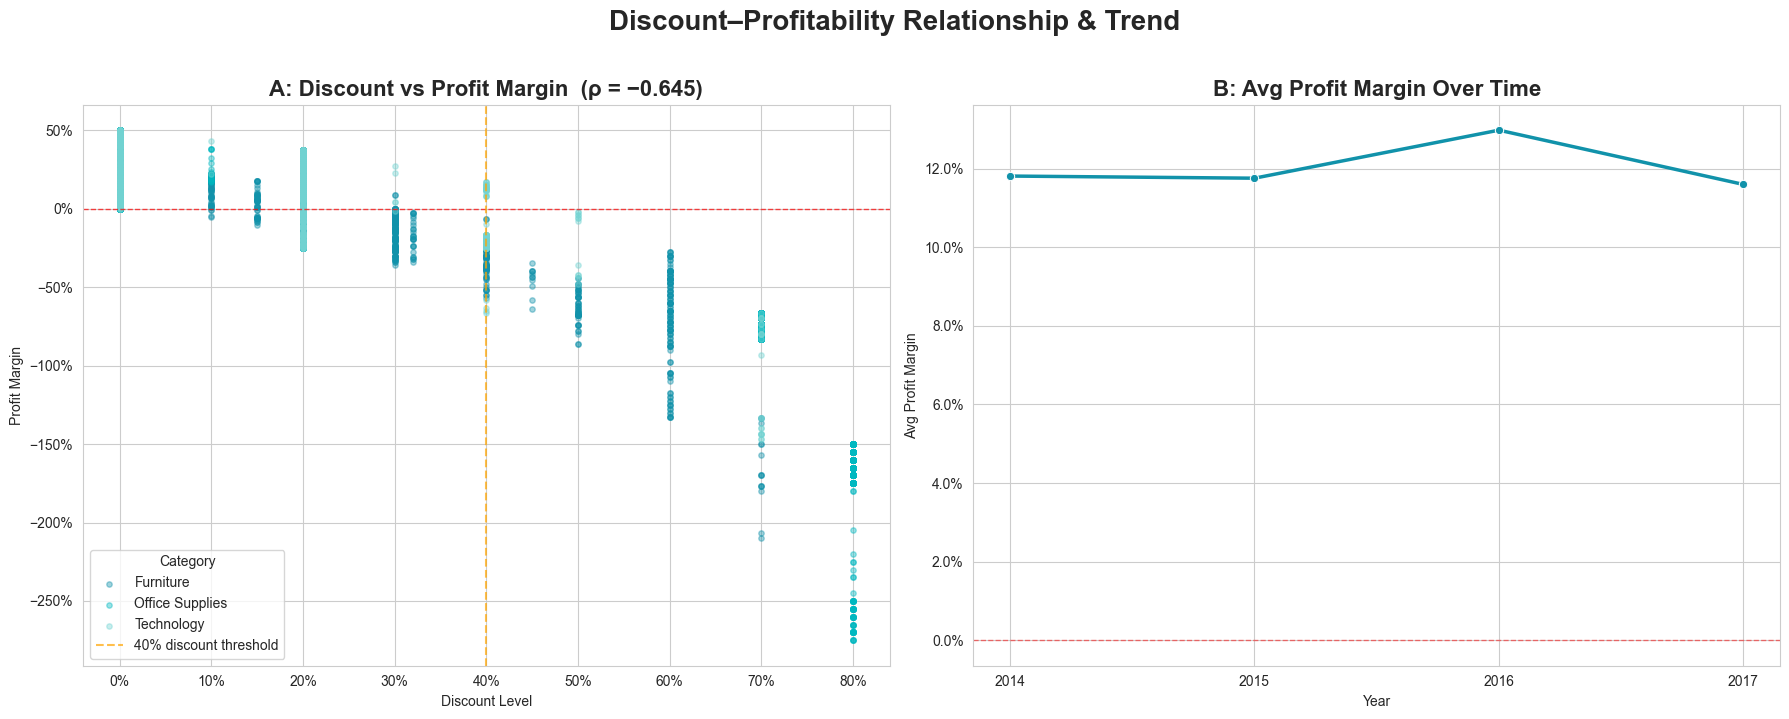

In [154]:

import os
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=False)

# Discount vs Profit Margin
category_colors = {'Furniture': '#1192AA', 'Office Supplies': '#00B8C0', 'Technology': '#73D4D3'}

for cat, grp in df.groupby('Category'):
    axes[0].scatter(
        grp['Discount'],
        grp['Profit Margin'],
        label=cat,
        color=category_colors[cat],
        alpha=0.4,
        s=15
    )

axes[0].axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7)
axes[0].axvline(0.4, color='orange', linestyle='--', linewidth=1.5, alpha=0.7, label='40% discount threshold')
axes[0].set_title("A: Discount vs Profit Margin  (ρ = −0.645)", fontsize=16, weight='bold')
axes[0].set_xlabel("Discount Level")
axes[0].set_ylabel("Profit Margin")
axes[0].legend(title='Category', loc='lower left')
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

# Panel B: Average Profit Margin by Year 
yearly_margin = df.groupby('Year')['Profit Margin'].mean().reset_index()

sns.lineplot(
    data=yearly_margin,
    x='Year',
    y='Profit Margin',
    marker='o',
    color='#1192AA',
    linewidth=2.5,
    ax=axes[1]
)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_title("B: Avg Profit Margin Over Time", fontsize=16, weight='bold')
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Avg Profit Margin")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes[1].set_xticks(yearly_margin['Year'])

plt.suptitle("Discount–Profitability Relationship & Trend", fontsize=20, weight='bold', y=1.02)
plt.tight_layout()
os.makedirs('../output/images', exist_ok=True)
plt.savefig('../output/images/03_discount_vs_margin.png', dpi=150, bbox_inches='tight')
plt.show()

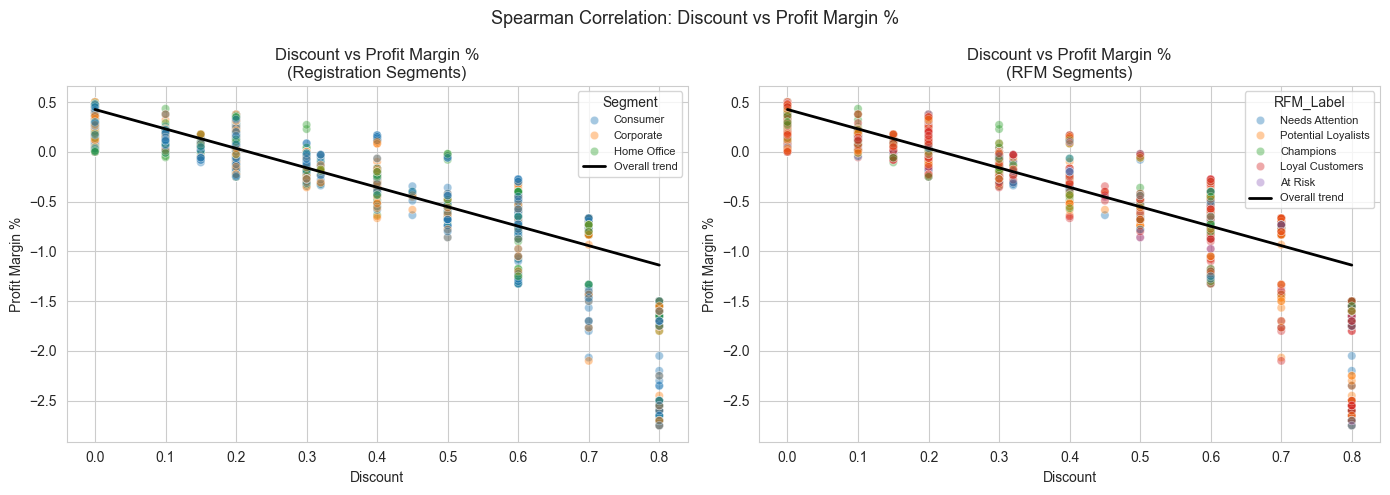

In [155]:
# ── 6.4 Visualisation: Discount vs Profit Margin % (all segments) ─────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (seg_col, title) in zip(axes, [('Segment', 'Registration Segments'), ('RFM_Label', 'RFM Segments')]):
    sns.scatterplot(
        data=df,
        x='Discount',
        y='Profit Margin %',
        hue=seg_col,
        alpha=0.4,
        ax=ax
    )

    # Overall regression line (for visual reference only — not a parametric claim)
    x_vals = df['Discount'].dropna()
    y_vals = df.loc[df['Discount'].notna(), 'Profit Margin %']
    m, b = np.polyfit(x_vals, y_vals, 1)
    x_sorted = np.sort(x_vals)
    ax.plot(x_sorted, m * x_sorted + b, color='black', linewidth=2, label='Overall trend')

    ax.set_title(f'Discount vs Profit Margin %\n({title})')
    ax.set_xlabel('Discount')
    ax.set_ylabel('Profit Margin %')
    ax.legend(title=seg_col, fontsize=8)

plt.suptitle('Spearman Correlation: Discount vs Profit Margin %', fontsize=13)
plt.tight_layout()
plt.savefig('spearman_discount_margin.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Pairwise Correlation Analysis

A pairplot of key continuous variables, coloured by year, visualises all pairwise relationships simultaneously - supplementing individual Spearman tests with a multivariate view.


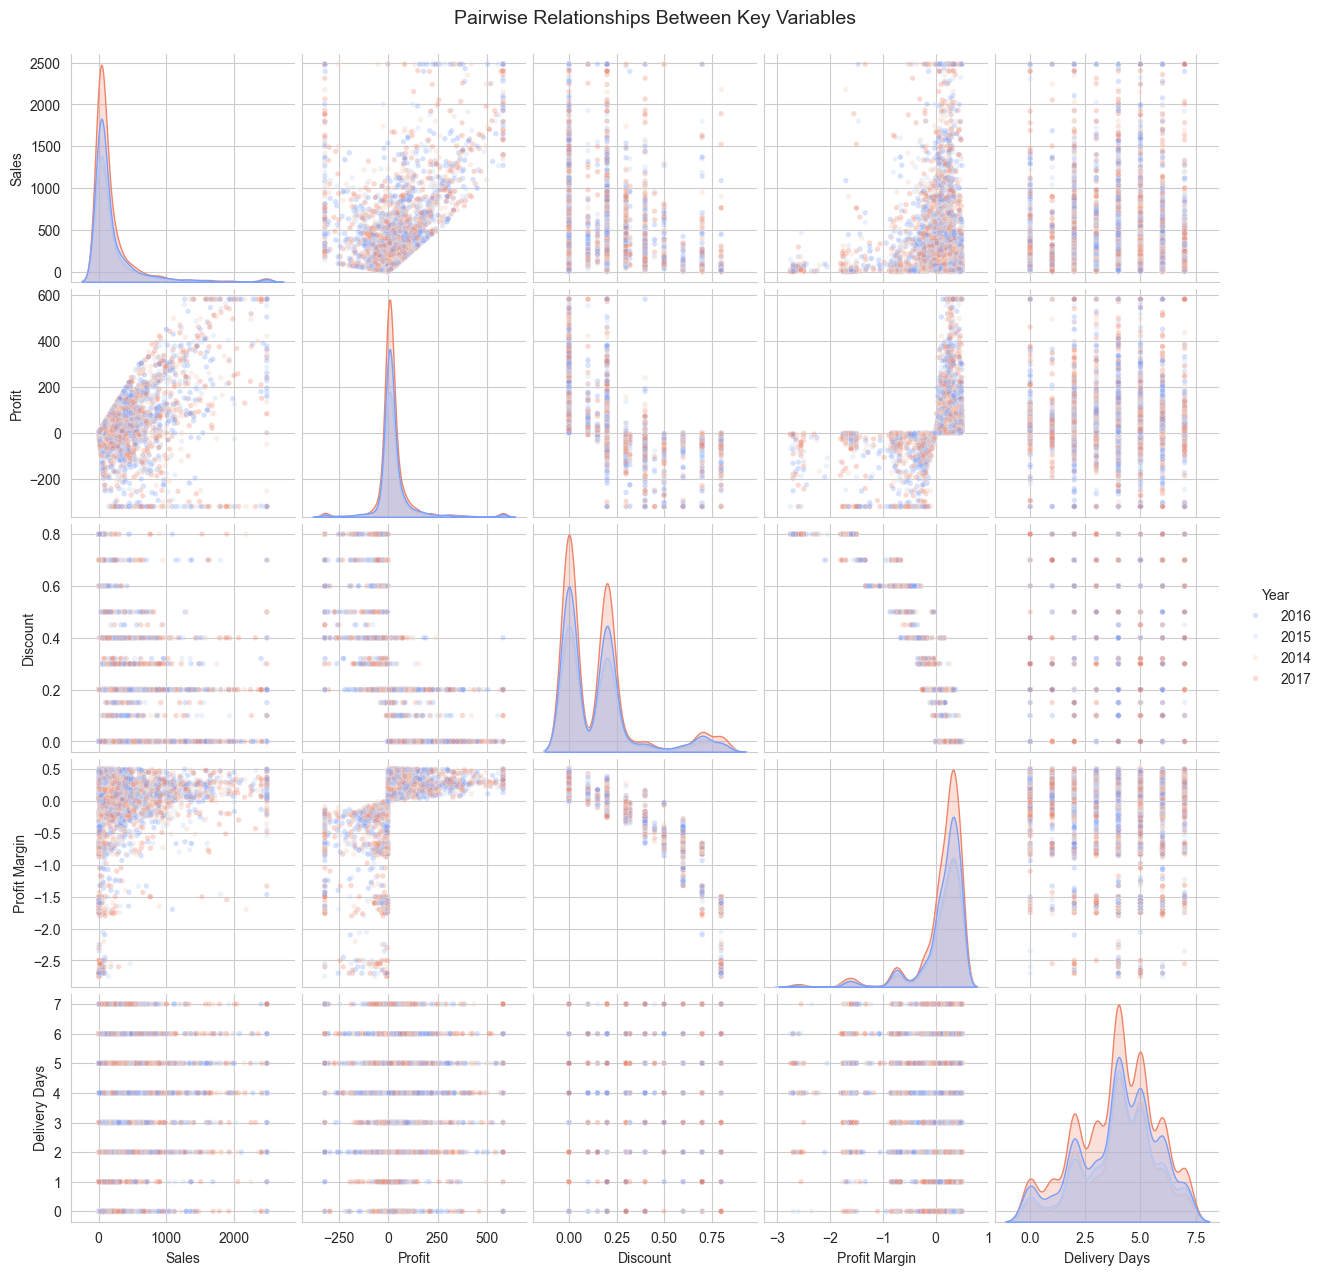

In [156]:
# Define key variables
cols = ['Sales', 'Profit', 'Discount', 'Profit Margin', 'Delivery Days']

# Clip extreme outliers so plots are readable
df_plot = df[cols + ['Year']].copy()
df_plot['Sales']  = df_plot['Sales'].clip(upper=df['Sales'].quantile(0.99))
df_plot['Profit'] = df_plot['Profit'].clip(
    lower=df['Profit'].quantile(0.01),
    upper=df['Profit'].quantile(0.99)
)
df_plot['Year'] = df_plot['Year'].astype(str)

# Create the pairplot

g = sns.pairplot(
    df_plot,
    vars=cols,
    hue='Year',
    palette="coolwarm",
    plot_kws={'alpha': 0.3, 's': 15},
    diag_kind='kde'
)

g.figure.suptitle("Pairwise Relationships Between Key Variables", fontsize=14, y=1.02)
os.makedirs('../output/images', exist_ok=True)
plt.savefig('../output/images/03_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

The pairplot reveals four key patterns across the five variables, with year shown via coolwarm (blue = 2014, red = 2017):

**Discount × Profit Margin (strongest signal):** The most visually striking panel. As discount increases, profit margin drops sharply and consistently into negative territory. The fan-shaped scatter confirms the Spearman result (ρ = −0.645) — this is the single strongest pairwise relationship in the dataset and the clearest lever for improving profitability.

**Discount × Profit:** A similar pattern — higher discounts push individual transaction profit below zero. The density of points at specific discount levels (0%, 20%, 30%, 40%, etc.) reflects a discrete discount structure, not a continuous one.

**Sales × Profit:** A moderate positive relationship with wide spread. High-sales transactions tend to be profitable, but the relationship is noisy — large orders can still produce losses when heavily discounted. The long tail on Sales (even after 99th-percentile clipping) pulls some points far right.

**Delivery Days:** Essentially uncorrelated with every other variable. The scatter panels involving Delivery Days show no pattern — delivery speed is determined entirely by ship mode choice, not by order size, profitability, or discount level.

**Year (colour):** No visible clustering by year across any panel. The four years overlap almost completely, indicating that the structural relationships between these variables did not change materially from 2014 to 2017. Trends are subtle and only detectable at the aggregate level (as shown in the Avg Profit Margin by Year line chart).

---
## 9. Save Results

In [157]:
import os

inference_summary = pd.DataFrame([
    {'Test': 'CI — Mean Sales',
     'Result': 'CI: [$217.64, $242.08]',
     'Significant': 'Yes',
     'Business Implication': 'Mean transaction value is stable and well-estimated; budget forecasting is reliable'},

    {'Test': 'Mann-Whitney — West vs Central Profit',
     'Result': 'p<0.001, r=0.234 (small)',
     'Significant': 'Yes',
     'Business Implication': 'West significantly more profitable than Central, but effect is small — not the primary driver'},

    {'Test': 'Kruskal-Wallis — Profit by Region',
     'Result': 'H=227.90, p<0.001 — 5/6 pairs significant',
     'Significant': 'Yes',
     'Business Implication': 'Regional profit differences are real; West leads, Central lags — resource allocation should reflect this'},

    {'Test': 'Kruskal-Wallis — Sales by Segment',
     'Result': 'H=0.68, p=0.710',
     'Significant': 'No',
     'Business Implication': 'Sales do not differ meaningfully across segments — all segments spend similarly per transaction'},

    {'Test': 'Chi-Square — Segment × Category',
     'Result': 'χ²=1.46, p=0.834, V=0.009',
     'Significant': 'No',
     'Business Implication': 'Segments show no category preference — cross-sell strategy cannot be driven by segment alone'},

    {'Test': 'Chi-Square — Discount × Category',
     'Result': 'p<0.001, V=0.230 (moderate)',
     'Significant': 'Yes',
     'Business Implication': 'Discounting is unevenly applied across categories — Furniture and Binders receive the heaviest discounts'},

    {'Test': 'Spearman — Discount vs Profit Margin',
     'Result': 'ρ=−0.645, p<0.001 (strong)',
     'Significant': 'Yes',
     'Business Implication': 'Discounting is the strongest driver of margin erosion — reducing high discounts is the clearest lever for profitability'},
])

os.makedirs('../output/kpis', exist_ok=True)
inference_summary.to_csv('../output/kpis/inference_summary.csv', index=False)
print("Saved inference_summary.csv")
inference_summary

Saved inference_summary.csv


,Test,Result,Significant,Business Implication
0,CI — Mean Sales,"CI: [$217.64, $242.08]",Yes,Mean transaction value is stable and well-esti...
1,Mann-Whitney — West vs Central Profit,"p<0.001, r=0.234 (small)",Yes,West significantly more profitable than Centra...
2,Kruskal-Wallis — Profit by Region,"H=227.90, p<0.001 — 5/6 pairs significant",Yes,Regional profit differences are real; West lea...
3,Kruskal-Wallis — Sales by Segment,"H=0.68, p=0.710",No,Sales do not differ meaningfully across segmen...
4,Chi-Square — Segment × Category,"χ²=1.46, p=0.834, V=0.009",No,Segments show no category preference — cross-s...
5,Chi-Square — Discount × Category,"p<0.001, V=0.230 (moderate)",Yes,Discounting is unevenly applied across categor...
6,Spearman — Discount vs Profit Margin,"ρ=−0.645, p<0.001 (strong)",Yes,Discounting is the strongest driver of margin ...


### 9.2 Comprehensive Results Summary (all tests)

In [158]:
all_results = pd.DataFrame([
    # Confidence Intervals (narrative only — see CI tables above)
    # kruskal
    {'Category': 'Kruskal', 'Test': 'Profit by Segment',    'Segmentation': 'Registration', 'Statistic': h_1,   'p-value': p_1},
    {'Category': 'Kruskal', 'Test': 'Sales by Segment',     'Segmentation': 'Registration', 'Statistic': h_2, 'p-value': p_2},
    {'Category': 'Kruskal', 'Test': 'Profit Margin%',  'Segmentation': 'Registration', 'Statistic': h_3, 'p-value': p_3},
    {'Category': 'Kruskal', 'Test': 'Discount by Segmen',        'Segmentation': 'Registration', 'Statistic': h_4,    'p-value': p_4},
    {'Category': 'Kruskal', 'Test': 'Profit by RFM',        'Segmentation': 'RFM',          'Statistic': h_5,    'p-value': p_5},
    {'Category': 'Kruskal', 'Test': 'Sales by RFM',         'Segmentation': 'RFM',          'Statistic': h_6,  'p-value': p_6},
    {'Category': 'Kruskal', 'Test': 'Profit Margin% by RFM',         'Segmentation': 'RFM',          'Statistic': h_7,  'p-value': p_7},
    {'Category': 'Kruskal', 'Test': 'Discount by RFM',  'Segmentation': 'RFM',          'Statistic': h_8,'p-value': p_8},
    # ANOVA
    {'Category': 'ANOVA', 'Test': 'Profit by Segment',    'Segmentation': 'Registration', 'Statistic': f_stat_1,   'p-value': p_value_1},
    {'Category': 'ANOVA', 'Test': 'Sales by Segment',     'Segmentation': 'Registration', 'Statistic': f_stat_2, 'p-value': p_value_2},
    {'Category': 'ANOVA', 'Test': 'Profit Margin%',  'Segmentation': 'Registration', 'Statistic': f_stat_3, 'p-value': p_value_3},
    {'Category': 'ANOVA', 'Test': 'Discount by Segmen',        'Segmentation': 'Registration', 'Statistic': f_stat_4,    'p-value': p_value_4},
    {'Category': 'ANOVA', 'Test': 'Profit by RFM',        'Segmentation': 'RFM',          'Statistic': f_stat_5,    'p-value': p_value_5},
    {'Category': 'ANOVA', 'Test': 'Sales by RFM',         'Segmentation': 'RFM',          'Statistic': f_stat_6,  'p-value': p_value_6},
    {'Category': 'ANOVA', 'Test': 'Profit Margin% by RFM',         'Segmentation': 'RFM',          'Statistic': f_stat_7,  'p-value': p_value_7},
    {'Category': 'ANOVA', 'Test': 'Discount by RFM',  'Segmentation': 'RFM',          'Statistic': f_stat_8,'p-value': p_value_8},
    # Chi-Square
    {'Category': 'Chi-Sq','Test': 'Segment × Discount',   'Segmentation': 'Registration', 'Statistic': chi2_1,   'p-value': p1},
    {'Category': 'Chi-Sq','Test': 'Segment × Category',   'Segmentation': 'Registration', 'Statistic': chi2_2,   'p-value': p2},
    {'Category': 'Chi-Sq','Test': 'Segment × Ship Mode',  'Segmentation': 'Registration', 'Statistic': chi2_3,   'p-value': p3},
    {'Category': 'Chi-Sq','Test': 'Segment × Quarter',    'Segmentation': 'Registration', 'Statistic': chi2_4,   'p-value': p4},
     {'Category': 'Chi-Sq', 'Test': 'RFM Segment × Discount Band',    'Segmentation': 'RFM', 'Statistic': round(chi2_5,2), 'p-value': round(p5,4)},
    {'Category': 'Chi-Sq', 'Test': 'RFM Segment × Category',        'Segmentation': 'RFM',          'Statistic': round(chi2_6,2), 'p-value': round(p6,4)},
    {'Category': 'Chi-Sq', 'Test': 'RFM Segment × Ship Mode',         'Segmentation': 'RFM', 'Statistic': round(chi2_7,2), 'p-value': round(p7,4)},
    {'Category': 'Chi-Sq', 'Test': 'RFM Segment × Quarter',             'Segmentation': 'RFM',          'Statistic': round(chi2_8,2), 'p-value': round(p8,4)}
])
   

all_results['Statistic'] = all_results['Statistic'].round(3)
all_results['p-value']   = all_results['p-value'].round(4)
all_results['Significant?'] = all_results['p-value'].apply(lambda p: '✅ Yes' if p < 0.05 else '❌ No')

all_results.to_csv("../data/all_results.csv", index=False)
print("✅ Clean dataset saved to ../data/all_results.csv")

print("\n" + "="*70)
print("COMPLETE INFERENTIAL RESULTS SUMMARY")
print("="*70)
print(all_results[['Category','Test','Segmentation','Statistic','p-value','Significant?']].to_string(index=False))

✅ Clean dataset saved to ../data/all_results.csv

COMPLETE INFERENTIAL RESULTS SUMMARY
Category                        Test Segmentation  Statistic  p-value Significant?
 Kruskal           Profit by Segment Registration      4.373   0.1123         ❌ No
 Kruskal            Sales by Segment Registration      0.684   0.7103         ❌ No
 Kruskal              Profit Margin% Registration      9.597   0.0082        ✅ Yes
 Kruskal          Discount by Segmen Registration      6.925   0.0313        ✅ Yes
 Kruskal               Profit by RFM          RFM    158.801   0.0000        ✅ Yes
 Kruskal                Sales by RFM          RFM     26.404   0.0000        ✅ Yes
 Kruskal       Profit Margin% by RFM          RFM     62.710   0.0000        ✅ Yes
 Kruskal             Discount by RFM          RFM     95.208   0.0000        ✅ Yes
   ANOVA           Profit by Segment Registration      0.898   0.4074         ❌ No
   ANOVA            Sales by Segment Registration      0.595   0.5515         ❌ No


---
## 10. Conclusions

> **Taken together, the inferential results tell a consistent story.**

> **Registration-based segments** (Consumer, Corporate, Home Office) are largely statistically indistinct on financial metrics: ANOVA and Kruskal-Wallis find no significant differences in profit, sales, margin, or discount across these labels. The only meaningful distinctions are behavioural - shipping mode preference and seasonal purchasing patterns - confirmed by Chi-Square tests.

> **RFM segments**, by contrast, show highly significant differences across all four financial metrics (profit, sales, margin, discount), confirming that behavioural segmentation is far more powerful at capturing true performance differences. All four Chi-Square associations (discount band, category, shipping mode, purchase quarter) are also highly significant for RFM segments.

> **The strongest single finding** is the Spearman correlation between Discount and Profit Margin (rho = -0.645, p < 0.001), consistent across all segments. Discounting policy is the clearest lever for profitability improvement.

> **Practical implication:** management should prioritise RFM-based segmentation as the primary framework for both profitability analysis and targeted strategy. Registration segments remain useful only for operational decisions (logistics, campaign timing). Discount policy should be the first intervention target, with a hard cap at 20% to eliminate the loss-making orders identified in the Chi-Square and descriptive analyses.
